<a href="https://colab.research.google.com/github/JSheleg/ut_austin_aiml_cert/blob/main/Sheleg_CV_Seedling_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Computer Vision: Plant Seedlings Classification

## Problem Statement

### Context

In recent times, the field of agriculture has been in urgent need of modernizing, since the amount of manual work people need to put in to check if plants are growing correctly is still highly extensive. Despite several advances in agricultural technology, people working in the agricultural industry still need to have the ability to sort and recognize different plants and weeds, which takes a lot of time and effort in the long term. The potential is ripe for this trillion-dollar industry to be greatly impacted by technological innovations that cut down on the requirement for manual labor, and this is where Artificial Intelligence can actually benefit the workers in this field, as **the time and energy required to identify plant seedlings will be greatly shortened by the use of AI and Deep Learning.** The ability to do so far more efficiently and even more effectively than experienced manual labor, could lead to better crop yields, the freeing up of human inolvement for higher-order agricultural decision making, and in the long term will result in more sustainable environmental practices in agriculture as well.


### Objective

The aim of this project is to Build a Convolutional Neural Netowrk to classify plant seedlings into their respective categories.

### Data Dictionary

The Aarhus University Signal Processing group, in collaboration with the University of Southern Denmark, has recently released a dataset containing **images of unique plants belonging to 12 different species.**

- The dataset can be download from Olympus.
- The data file names are:
    - images.npy
    - Labels.csv
- Due to the large volume of data, the images were converted to the images.npy file and the labels are also put into Labels.csv, so that you can work on the data/project seamlessly without having to worry about the high data volume.

- The goal of the project is to create a classifier capable of determining a plant's species from an image.

**List of Species**

- Black-grass
- Charlock
- Cleavers
- Common Chickweed
- Common Wheat
- Fat Hen
- Loose Silky-bent
- Maize
- Scentless Mayweed
- Shepherds Purse
- Small-flowered Cranesbill
- Sugar beet

### **Note: Please use GPU runtime on Google Colab to execute the code faster.**

## Importing necessary libraries

In [1]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install tensorflow==2.15.0 scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 opencv-python==4.8.0.76 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [2]:
import os
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2                                                                                       # Importing openCV for image processing
import seaborn as sns                                                                            # Importing seaborn to plot graphs


# Tensorflow modules
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report                                                     # Importing confusion_matrix to plot the confusion matrix
from sklearn.preprocessing import LabelBinarizer
# Display images using OpenCV
from google.colab.patches import cv2_imshow                                                      # Importing cv2_imshow from google.patches to display images
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend
from keras.callbacks import ReduceLROnPlateau
import random
# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

## Loading the dataset

In [3]:
# Uncomment and run the below code if you are using google colab
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# Load image file of dataset
images = np.load('/content/drive/MyDrive/UT_Austin_ML/computer_vision/project_seedling_classification/images.npy')

In [5]:
# Load labels file of dataset
labels = pd.read_csv('/content/drive/MyDrive/UT_Austin_ML/computer_vision/project_seedling_classification/Labels.csv')

## Data Overview

### Understand the shape of the dataset

In [6]:
images.shape

(4750, 128, 128, 3)

In [7]:
labels.shape

(4750, 1)

In [8]:
labels.Label.unique()

array(['Small-flowered Cranesbill', 'Fat Hen', 'Shepherds Purse',
       'Common wheat', 'Common Chickweed', 'Charlock', 'Cleavers',
       'Scentless Mayweed', 'Sugar beet', 'Maize', 'Black-grass',
       'Loose Silky-bent'], dtype=object)

In [9]:
labels.Label.nunique()

12

* The plant seedlings dataset contains a total of 4750 images that are 128 x 128 square images
* 3 indicates 3 channels, which indicates colored images (RGB) with colors Red, Green and Blue
* There are 12 target labels and they are as follows:
  * 'Small-flowered Cranesbill'
  * 'Fat Hen'
  * 'Shepherds Purse'
  * 'Common wheat'
  * 'Common Chickweed'
  * 'Charlock'
  * 'Cleavers'
  * 'Scentless Mayweed'
  * 'Sugar beet'
  * 'Maize'
  * 'Black-grass'
  * 'Loose Silky-bent'

## Exploratory Data Analysis

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you understand the data better.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

1. How are these different category plant images different from each other?
2. Is the dataset provided an imbalance? (Check with using bar plots)

### Data Visualization

In [10]:
labels.value_counts()

,count
Label,
Loose Silky-bent,654
Common Chickweed,611
Scentless Mayweed,516
Small-flowered Cranesbill,496
Fat Hen,475
Charlock,390
Sugar beet,385
Cleavers,287
Black-grass,263


In [11]:
labels.Label.value_counts(1)

,proportion
Label,
Loose Silky-bent,0.137684
Common Chickweed,0.128632
Scentless Mayweed,0.108632
Small-flowered Cranesbill,0.104421
Fat Hen,0.100000
Charlock,0.082105
Sugar beet,0.081053
Cleavers,0.060421
Black-grass,0.055368


In [12]:
labels.Label.unique()

array(['Small-flowered Cranesbill', 'Fat Hen', 'Shepherds Purse',
       'Common wheat', 'Common Chickweed', 'Charlock', 'Cleavers',
       'Scentless Mayweed', 'Sugar beet', 'Maize', 'Black-grass',
       'Loose Silky-bent'], dtype=object)

array([[[ 30,  47,  63],
        [ 30,  50,  60],
        [ 34,  47,  63],
        ...,
        [ 48,  59,  74],
        [ 42,  54,  69],
        [ 44,  56,  70]],

       [[ 30,  49,  67],
        [ 26,  47,  60],
        [ 30,  40,  61],
        ...,
        [ 50,  64,  76],
        [ 52,  67,  78],
        [ 45,  56,  72]],

       [[ 23,  46,  65],
        [ 27,  48,  64],
        [ 25,  40,  59],
        ...,
        [ 39,  59,  81],
        [ 47,  62,  79],
        [ 42,  54,  69]],

       ...,

       [[ 32,  54,  72],
        [ 58,  82,  95],
        [ 72,  96, 109],
        ...,
        [ 60,  80,  99],
        [ 50,  72,  92],
        [ 45,  64,  84]],

       [[ 31,  51,  67],
        [ 25,  50,  64],
        [ 38,  64,  80],
        ...,
        [ 63,  83, 101],
        [ 57,  78,  96],
        [ 50,  69,  89]],

       [[ 18,  32,  56],
        [ 16,  27,  50],
        [ 34,  49,  71],
        ...,
        [ 59,  84, 101],
        [ 55,  80,  97],
        [ 39,  59,  82]]], dtype=uint8)
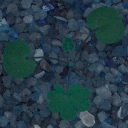

In [13]:
indices = labels[labels['Label'] == 'Small-flowered Cranesbill'].index
filtered_images = images[indices]
filtered_images[1]

array([[[44, 44, 55],
        [45, 45, 60],
        [43, 43, 59],
        ...,
        [69, 67, 76],
        [70, 67, 77],
        [73, 70, 79]],

       [[55, 53, 67],
        [61, 60, 74],
        [54, 54, 66],
        ...,
        [69, 67, 75],
        [67, 65, 73],
        [70, 66, 75]],

       [[66, 64, 75],
        [60, 62, 69],
        [60, 61, 68],
        ...,
        [64, 64, 72],
        [65, 65, 70],
        [66, 64, 69]],

       ...,

       [[45, 65, 87],
        [41, 50, 72],
        [23, 29, 53],
        ...,
        [48, 65, 88],
        [41, 62, 85],
        [47, 67, 89]],

       [[42, 62, 86],
        [42, 51, 75],
        [43, 49, 73],
        ...,
        [37, 55, 73],
        [61, 78, 97],
        [58, 75, 96]],

       [[36, 52, 78],
        [44, 53, 78],
        [35, 47, 75],
        ...,
        [58, 72, 85],
        [58, 73, 88],
        [58, 72, 88]]], dtype=uint8)
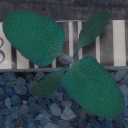

In [14]:
indices = labels[labels['Label'] == 'Fat Hen'].index
filtered_images = images[indices]
filtered_images[4]

array([[[ 41,  49,  67],
        [ 28,  42,  60],
        [ 68,  82,  98],
        ...,
        [ 65,  78,  95],
        [ 66,  79,  99],
        [ 24,  51,  81]],

       [[ 35,  49,  64],
        [ 20,  35,  59],
        [ 66,  78,  95],
        ...,
        [ 63,  77,  91],
        [ 81,  93, 107],
        [ 54,  72,  92]],

       [[ 39,  52,  72],
        [ 26,  40,  64],
        [ 32,  41,  62],
        ...,
        [ 58,  72,  87],
        [ 61,  74,  87],
        [ 54,  70,  87]],

       ...,

       [[ 62,  75,  92],
        [ 60,  74,  89],
        [ 53,  71,  86],
        ...,
        [ 51,  66,  87],
        [ 52,  67,  87],
        [ 60,  73,  94]],

       [[ 60,  75,  94],
        [ 63,  78,  94],
        [ 67,  79,  94],
        ...,
        [ 41,  58,  81],
        [ 33,  45,  80],
        [ 48,  57,  89]],

       [[ 75,  94, 109],
        [ 63,  82, 102],
        [ 62,  79,  99],
        ...,
        [ 27,  38,  78],
        [ 26,  37,  80],
        [ 26,  37,  82]]], dtype=uint8)
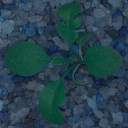

In [15]:
indices = labels[labels['Label'] == 'Shepherds Purse'].index
filtered_images = images[indices]
filtered_images[75]

array([[[ 86,  91,  96],
        [ 66,  74,  78],
        [ 34,  38,  45],
        ...,
        [ 79,  94, 106],
        [ 75,  87, 106],
        [ 49,  67,  85]],

       [[ 84,  89,  97],
        [ 74,  79,  82],
        [ 45,  47,  52],
        ...,
        [ 51,  64,  79],
        [ 56,  69,  89],
        [ 36,  52,  74]],

       [[ 77,  84,  93],
        [ 73,  76,  82],
        [ 39,  41,  49],
        ...,
        [ 61,  76,  92],
        [ 71,  82,  94],
        [ 52,  67,  83]],

       ...,

       [[ 36,  61,  83],
        [ 44,  70,  85],
        [ 40,  65,  83],
        ...,
        [ 40,  49,  61],
        [ 39,  49,  65],
        [ 30,  41,  55]],

       [[ 16,  52,  81],
        [ 17,  52,  80],
        [ 40,  67,  83],
        ...,
        [ 29,  40,  53],
        [ 34,  47,  60],
        [ 41,  52,  63]],

       [[ 18,  53,  81],
        [ 15,  49,  77],
        [ 32,  54,  78],
        ...,
        [ 20,  35,  54],
        [ 36,  51,  64],
        [ 41,  51,  64]]], dtype=uint8)
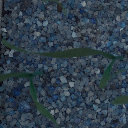

In [16]:
indices = labels[labels['Label'] == 'Common wheat'].index
filtered_images = images[indices]
filtered_images[23]

array([[[ 44,  75, 102],
        [ 47,  75, 104],
        [ 48,  75, 103],
        ...,
        [ 78,  95, 110],
        [ 73,  87, 103],
        [ 72,  85, 104]],

       [[ 49,  82, 107],
        [ 47,  77, 107],
        [ 49,  77, 107],
        ...,
        [ 79,  95, 111],
        [ 72,  86, 105],
        [ 48,  64,  87]],

       [[ 35,  73, 100],
        [ 57,  88, 115],
        [ 49,  81, 109],
        ...,
        [ 77,  96, 110],
        [ 71,  89, 108],
        [ 45,  67,  90]],

       ...,

       [[ 82,  96, 106],
        [ 85,  99, 108],
        [ 82,  96, 108],
        ...,
        [ 49,  68,  84],
        [ 54,  75,  93],
        [ 57,  74,  89]],

       [[ 83,  94, 105],
        [ 81,  95, 104],
        [ 76,  92, 103],
        ...,
        [ 57,  74,  88],
        [ 47,  65,  80],
        [ 44,  57,  71]],

       [[ 82,  90, 102],
        [ 80,  92, 103],
        [ 79,  94, 106],
        ...,
        [ 39,  54,  72],
        [ 48,  58,  74],
        [ 41,  48,  62]]], dtype=uint8)
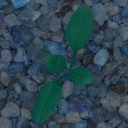

In [17]:
indices = labels[labels['Label'] == 'Common Chickweed'].index
filtered_images = images[indices]
filtered_images[3]

array([[[179, 171, 166],
        [180, 172, 168],
        [183, 174, 170],
        ...,
        [113, 108, 110],
        [102,  98, 103],
        [ 95,  90,  97]],

       [[175, 169, 165],
        [174, 168, 162],
        [175, 167, 162],
        ...,
        [116, 113, 113],
        [105, 103, 106],
        [ 93,  89,  94]],

       [[166, 162, 159],
        [152, 146, 149],
        [136, 127, 138],
        ...,
        [116, 113, 113],
        [109, 108, 107],
        [ 92,  87,  93]],

       ...,

       [[ 87, 106, 121],
        [106, 125, 138],
        [107, 128, 140],
        ...,
        [ 70,  84, 101],
        [ 72,  85, 100],
        [ 71,  84, 103]],

       [[ 82,  96, 111],
        [ 89, 104, 119],
        [ 91, 107, 126],
        ...,
        [ 65,  82, 100],
        [ 65,  81,  99],
        [ 65,  81, 102]],

       [[ 74,  88, 102],
        [ 86,  97, 109],
        [ 80,  89, 106],
        ...,
        [ 71,  93, 110],
        [ 65,  86, 103],
        [ 61,  80, 102]]], dtype=uint8)
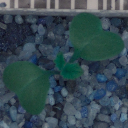

In [18]:
indices = labels[labels['Label'] == 'Charlock'].index
filtered_images = images[indices]
filtered_images[7]

array([[[109, 130, 140],
        [105, 124, 137],
        [ 90, 108, 128],
        ...,
        [ 42,  68, 100],
        [ 40,  67, 102],
        [ 46,  74, 106]],

       [[ 99, 121, 133],
        [ 85, 107, 127],
        [ 73,  95, 123],
        ...,
        [ 41,  65,  94],
        [ 42,  70, 101],
        [ 47,  76, 106]],

       [[ 78, 100, 120],
        [ 60,  83, 113],
        [ 77, 105, 131],
        ...,
        [ 45,  65,  91],
        [ 41,  65,  94],
        [ 44,  72, 100]],

       ...,

       [[ 52,  69,  88],
        [ 54,  68,  88],
        [ 42,  54,  74],
        ...,
        [ 32,  65, 106],
        [ 29,  65, 106],
        [ 34,  70, 109]],

       [[ 39,  50,  73],
        [ 43,  54,  76],
        [ 40,  50,  70],
        ...,
        [ 30,  61, 103],
        [ 30,  62, 105],
        [ 30,  64, 106]],

       [[ 31,  37,  61],
        [ 31,  38,  61],
        [ 32,  41,  60],
        ...,
        [ 37,  65, 102],
        [ 33,  63, 102],
        [ 36,  69, 105]]], dtype=uint8)
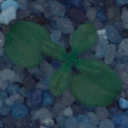

In [19]:
indices = labels[labels['Label'] == 'Cleavers'].index
filtered_images = images[indices]
filtered_images[17]

array([[[ 35,  40,  55],
        [ 58,  67,  77],
        [ 83,  93,  99],
        ...,
        [ 93, 105, 110],
        [108, 121, 123],
        [121, 133, 134]],

       [[ 40,  43,  53],
        [ 57,  62,  71],
        [ 68,  76,  82],
        ...,
        [ 73,  80,  94],
        [ 83,  93, 101],
        [ 94, 105, 109]],

       [[ 44,  45,  51],
        [ 44,  47,  53],
        [ 47,  51,  57],
        ...,
        [ 43,  50,  73],
        [ 56,  63,  79],
        [ 65,  76,  85]],

       ...,

       [[ 35,  44,  63],
        [ 38,  47,  64],
        [ 36,  45,  62],
        ...,
        [ 68,  88, 103],
        [ 63,  82,  98],
        [ 56,  71,  89]],

       [[ 30,  42,  61],
        [ 35,  46,  62],
        [ 33,  45,  59],
        ...,
        [ 67,  87, 103],
        [ 58,  79,  97],
        [ 51,  70,  91]],

       [[ 30,  45,  63],
        [ 34,  46,  61],
        [ 36,  48,  61],
        ...,
        [ 64,  85, 104],
        [ 57,  79,  99],
        [ 47,  69,  92]]], dtype=uint8)
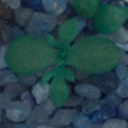

In [20]:
indices = labels[labels['Label'] == 'Scentless Mayweed'].index
filtered_images = images[indices]
filtered_images[7]

array([[[ 41,  41,  53],
        [ 37,  36,  49],
        [ 30,  30,  39],
        ...,
        [ 51,  52,  64],
        [ 54,  54,  63],
        [ 50,  49,  62]],

       [[ 41,  43,  53],
        [ 40,  41,  50],
        [ 42,  42,  51],
        ...,
        [ 53,  55,  64],
        [ 55,  56,  69],
        [ 55,  55,  61]],

       [[ 45,  45,  55],
        [ 42,  43,  54],
        [ 41,  41,  50],
        ...,
        [ 60,  62,  74],
        [ 55,  57,  65],
        [ 52,  51,  57]],

       ...,

       [[ 43,  63,  87],
        [ 23,  38,  63],
        [ 29,  47,  73],
        ...,
        [108, 107, 112],
        [108, 111, 114],
        [105, 105, 105]],

       [[ 49,  71,  91],
        [ 51,  71,  96],
        [ 56,  85, 113],
        ...,
        [ 99,  98, 105],
        [ 92,  89,  96],
        [ 88,  88,  90]],

       [[ 43,  62,  86],
        [ 49,  69,  91],
        [ 54,  80, 105],
        ...,
        [100,  97, 103],
        [ 97,  96, 103],
        [ 95,  93,  95]]], dtype=uint8)
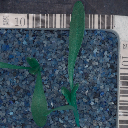

In [21]:
indices = labels[labels['Label'] == 'Sugar beet'].index
filtered_images = images[indices]
filtered_images[2]

array([[[ 59,  76,  91],
        [ 58,  74,  90],
        [ 57,  72,  90],
        ...,
        [ 54,  72,  91],
        [ 66,  82, 100],
        [ 60,  78,  96]],

       [[ 64,  79,  94],
        [ 64,  79,  95],
        [ 64,  78,  96],
        ...,
        [ 63,  81,  98],
        [ 69,  86, 104],
        [ 66,  84, 101]],

       [[ 67,  82,  96],
        [ 70,  85, 100],
        [ 68,  82,  99],
        ...,
        [ 65,  83,  99],
        [ 67,  84, 101],
        [ 69,  86, 102]],

       ...,

       [[ 27,  39,  61],
        [ 20,  30,  52],
        [ 31,  39,  59],
        ...,
        [ 62,  72,  85],
        [ 69,  78,  91],
        [ 64,  73,  86]],

       [[ 19,  28,  50],
        [ 20,  27,  49],
        [ 34,  39,  58],
        ...,
        [ 58,  68,  82],
        [ 67,  76,  89],
        [ 64,  73,  86]],

       [[ 22,  29,  51],
        [ 28,  32,  53],
        [ 35,  40,  58],
        ...,
        [ 61,  70,  83],
        [ 62,  71,  84],
        [ 62,  71,  85]]], dtype=uint8)
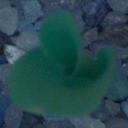

In [22]:
indices = labels[labels['Label'] == 'Maize'].index
filtered_images = images[indices]
filtered_images[117]

array([[[ 58,  71,  81],
        [ 37,  48,  56],
        [  9,  16,  16],
        ...,
        [ 54,  67,  81],
        [ 56,  69,  84],
        [ 36,  54,  72]],

       [[ 64,  87,  95],
        [ 49,  67,  76],
        [ 76,  90, 100],
        ...,
        [ 49,  64,  81],
        [ 47,  64,  82],
        [ 36,  56,  71]],

       [[ 67,  84,  94],
        [ 48,  63,  65],
        [ 48,  56,  61],
        ...,
        [ 51,  70,  86],
        [ 52,  69,  84],
        [ 26,  40,  55]],

       ...,

       [[ 30,  65,  51],
        [ 36,  70,  56],
        [ 40,  75,  65],
        ...,
        [ 48,  64,  84],
        [ 35,  52,  73],
        [ 38,  51,  78]],

       [[ 45,  78,  64],
        [ 46,  79,  64],
        [ 43,  71,  66],
        ...,
        [ 41,  57,  79],
        [ 42,  58,  76],
        [ 35,  54,  79]],

       [[ 40,  70,  59],
        [ 40,  76,  67],
        [ 54,  69,  81],
        ...,
        [ 39,  55,  75],
        [ 39,  54,  78],
        [ 25,  42,  76]]], dtype=uint8)
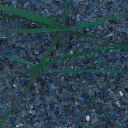

In [23]:
indices = labels[labels['Label'] == 'Black-grass'].index
filtered_images = images[indices]
filtered_images[89]

array([[[ 62,  80, 100],
        [ 61,  83, 103],
        [ 67,  85, 101],
        ...,
        [ 52,  52,  63],
        [ 54,  49,  63],
        [ 46,  44,  58]],

       [[ 61,  81,  97],
        [ 65,  85, 103],
        [ 66,  85, 100],
        ...,
        [ 55,  54,  61],
        [ 51,  53,  60],
        [ 57,  55,  63]],

       [[ 67,  83, 105],
        [ 75,  93, 110],
        [ 81, 101, 116],
        ...,
        [ 55,  52,  60],
        [ 55,  55,  63],
        [ 58,  57,  61]],

       ...,

       [[ 31,  43,  60],
        [ 30,  41,  56],
        [ 37,  49,  67],
        ...,
        [ 49,  51,  58],
        [ 52,  56,  68],
        [ 46,  48,  57]],

       [[ 34,  44,  62],
        [ 38,  48,  60],
        [ 35,  45,  63],
        ...,
        [ 55,  57,  63],
        [ 54,  59,  71],
        [ 56,  57,  63]],

       [[ 35,  46,  59],
        [ 31,  41,  57],
        [ 42,  53,  68],
        ...,
        [ 55,  57,  61],
        [ 55,  58,  67],
        [ 52,  53,  64]]], dtype=uint8)
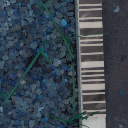

In [24]:
indices = labels[labels['Label'] == 'Loose Silky-bent'].index
filtered_images = images[indices]
filtered_images[100]

* `Small-flowered Cranesbill` - The seedling has oval/kidney shaped leaves with a very thin stem. It looks like the leaves tend to sepearte into smaller clusters.
* `Fat Hen` - The seedling leaves are long oval leaves that seem to grow thicker as they mature
* `Shepherds Purse` - Seedlings have a combination of pointed-ovals and long leaves with multiple seperate bumps in the leave
* `Common wheat` - Seedlings are long and thin and they look to twist as they grow
* `Common Chickweed` - Long oval leaves that end at a point at the end
* `Charlock` - Leaves grow starting like two circles together(vinn-diagram) and then as it matures, the leaves become more heart shaped
* `Cleavers` - Seedling's leaves are like 2 ovals pushed together on the long side of the oval. As it matures, it seems to blur together and turning more circular
* `Scentless Mayweed` - Seeding has a combination of leaves of ovals with a slightly flat side connected to the stem and oval shaped leaves with 2 additional leave sections coming out of the leaf itself.
* `Sugar beet` - Seedlings start at a point and spread out into an oval like a cone. It looks like it has a line splitting the leaf in half.
* `Maize` - Seedling has a mixture of triangluar shaped leaves with the leaves swirling together at the junction of the stem
* `Black-grass` - Seedling is long super thin leaves
* `Loose Silky-bent` - Seedling leaves are long super thin leaves that twist along the length of the leaf

In [25]:
# plot random images from each class
def plot_images(images,labels):
  num_classes=10                                                                  # Number of Classes
  categories=np.unique(labels)
  keys=dict(labels['Label'])                                                      # Obtaing the unique classes from y_train
  rows = 3                                                                        # Defining number of rows=3
  cols = 4                                                                        # Defining number of columns=4
  fig = plt.figure(figsize=(10, 8))                                               # Defining the figure size to 10x8
  for i in range(cols):
      for j in range(rows):
          random_index = np.random.randint(0, len(labels))                        # Generating random indices from the data and plotting the images
          ax = fig.add_subplot(rows, cols, i * rows + j + 1)                      # Adding subplots with 3 rows and 4 columns
          ax.imshow(images[random_index, :])                                      # Plotting the image
          ax.set_title(keys[random_index])
  plt.show()

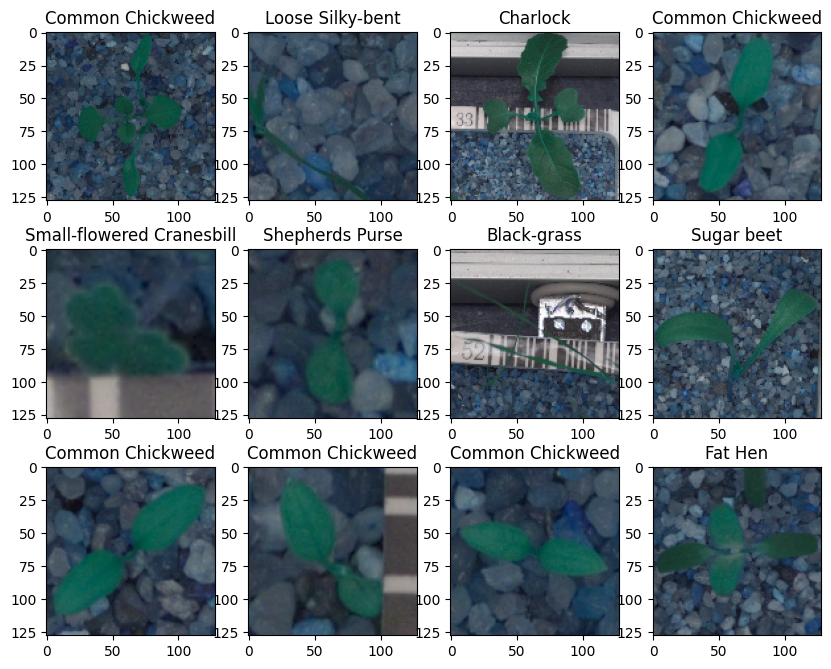

In [26]:
plot_images(images, labels)

Text(0.5, 0, 'Plant Categories')

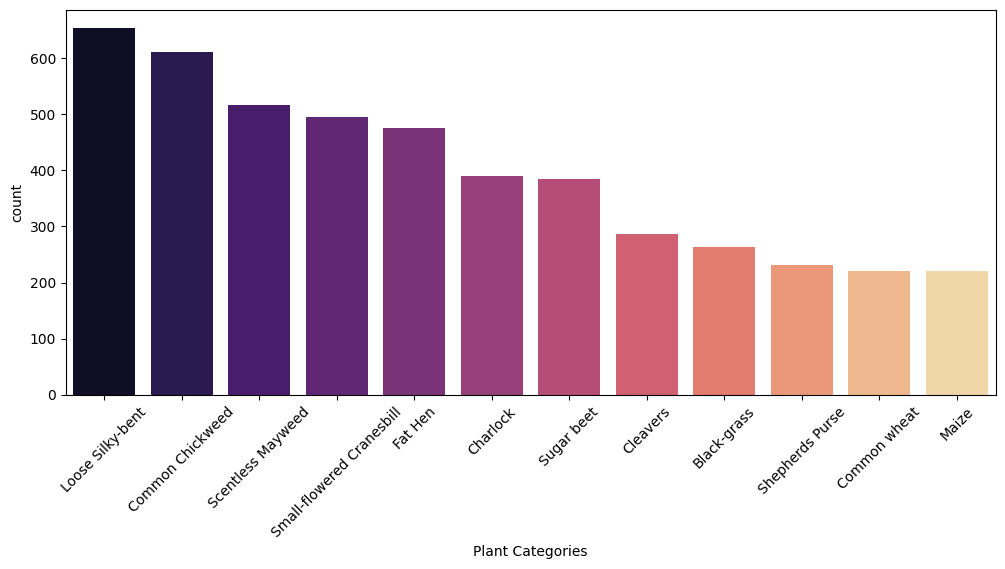

In [27]:
# Plot distribution for each category
plt.figure(figsize=(12,5))
sns.countplot(x=labels['Label'], orient='v', palette='magma', order = labels['Label'].value_counts().index)
plt.xticks(rotation=45)
plt.xlabel('Plant Categories')


* The plant categories with the most plant samples are Loose Silky-bent(654) and Common Chickweed (611)
* The plant categories with the least plant samples are Shepherds Purse(231), Common Wheat (221) and Maize (221)

## Data Pre-Processing

### Convert the BGR images to RGB images.

In [28]:
# deep copy of images array
images_rgb = np.copy(images)

In [29]:
# convert the images from BGR to RGB using cvtColor function
for i in range(len(images_rgb)):
  images_rgb[i] = cv2.cvtColor(images_rgb[i],cv2.COLOR_BGR2RGB)

array([[[ 78,  52,  35],
        [ 76,  49,  36],
        [ 69,  45,  31],
        ...,
        [114,  95,  78],
        [110,  93,  76],
        [109,  95,  80]],

       [[ 68,  46,  33],
        [ 73,  50,  37],
        [ 83,  65,  48],
        ...,
        [113,  96,  81],
        [105,  89,  74],
        [109,  95,  83]],

       [[ 68,  50,  34],
        [ 72,  52,  35],
        [101,  85,  70],
        ...,
        [112,  97,  83],
        [108,  94,  79],
        [107,  94,  79]],

       ...,

       [[ 69,  50,  35],
        [ 73,  57,  42],
        [ 72,  57,  42],
        ...,
        [ 92,  76,  60],
        [ 97,  81,  67],
        [ 95,  77,  64]],

       [[ 67,  52,  36],
        [ 78,  63,  48],
        [ 73,  57,  41],
        ...,
        [ 83,  66,  44],
        [ 91,  76,  58],
        [ 90,  74,  57]],

       [[ 70,  58,  44],
        [ 73,  57,  43],
        [ 72,  55,  40],
        ...,
        [ 92,  70,  41],
        [ 97,  78,  55],
        [ 96,  79,  61]]], dtype=uint8)
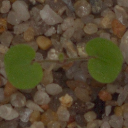

In [30]:
images_rgb[0]

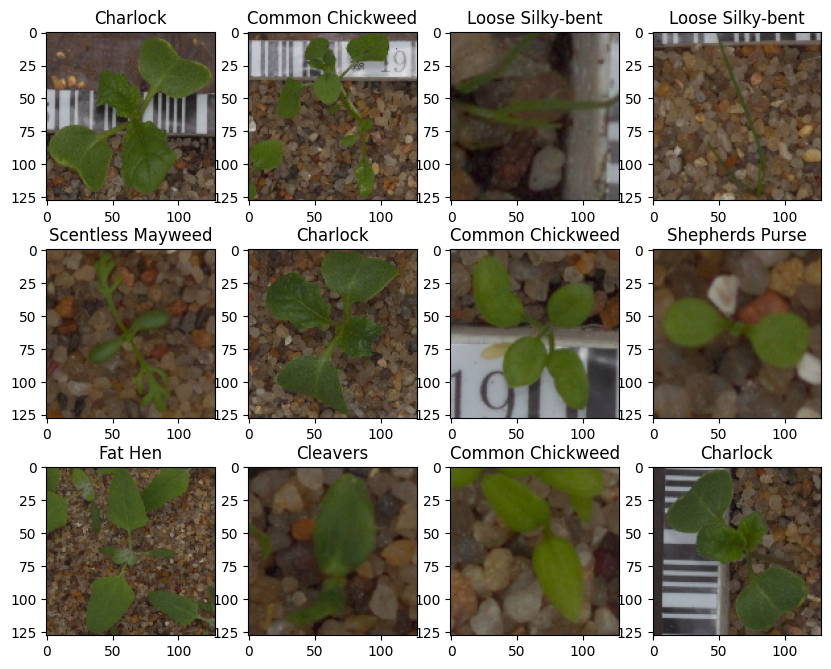

In [31]:
plot_images(images_rgb, labels)

* Images were converted from BGR to RGB.
* Some of the images are extremely blurry even at 128 x 128.

### Convert the BGR images to HSV images.

* HSV is good for object detection with poor lighting. I want to see if HSV might help further bring out the features of the seedlings

In [32]:
# deep copy of images array
images_hsv = np.copy(images)

In [33]:
# convert the images from BGR to RGB using cvtColor function
for i in range(len(images_hsv)):
  images_hsv[i] = cv2.cvtColor(images_hsv[i],cv2.COLOR_BGR2HSV)

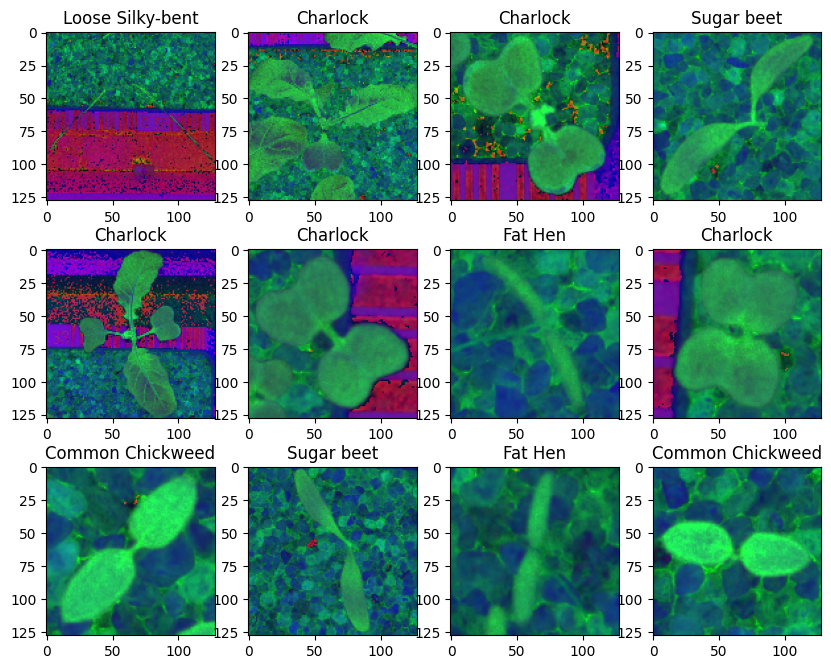

In [34]:
plot_images(images_hsv, labels)

* HSV brought a bunch of detail, but a good amount of noise was created by the background

### Resize the images

As the size of the images is large, it may be computationally expensive to train on these larger images; therefore, it is preferable to reduce the image size from 128 to 64.
* Both the RGB and the HSV images will be resized to reduce computational costs

In [35]:
# function to resize images
def resize_images_(images, new_size):
  resized_images = np.empty((images.shape[0], new_size[1], new_size[0], images.shape[3]) if images.ndim == 4 else (images.shape[0], new_size[1], new_size[0]), dtype=images.dtype)
  for i in range(images.shape[0]):
        resized_images[i] = cv2.resize(images[i], new_size, interpolation=cv2.INTER_LINEAR)
  return resized_images

In [36]:
# new size
size = (64, 64)

In [37]:
# resize rgb images
images_rgb_decreased = resize_images_(images_rgb, size)

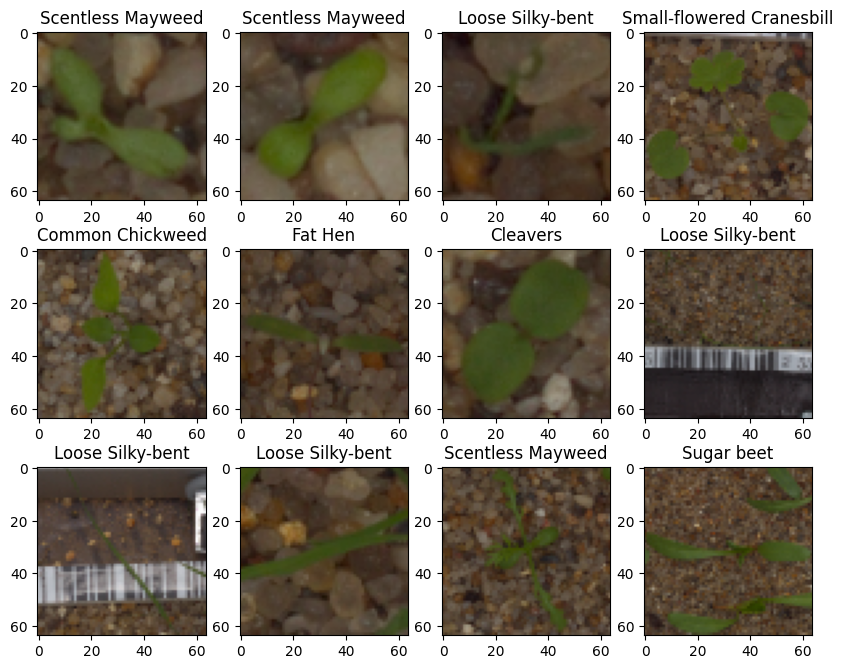

In [38]:
# view rgb images after size reduction
plot_images(images_rgb_decreased, labels)

* Images have reduced in size and has resulted in blurrier images all around. This makes since as pixels were removed.

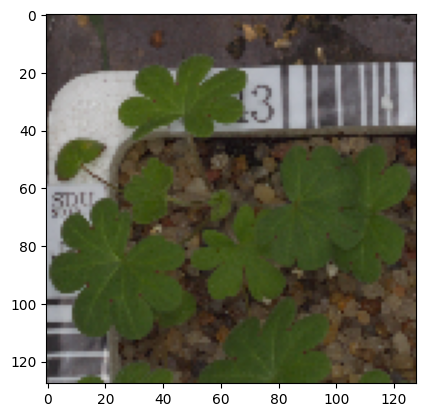

In [39]:
# view images before resizing
plt.imshow(images_rgb[3])

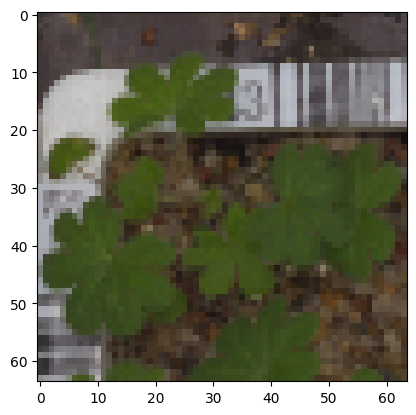

In [40]:
# view images after resizing
plt.imshow(images_rgb_decreased[3])

In [41]:
# resize hsv images
images_hsv_decreased = resize_images_(images_hsv, size)

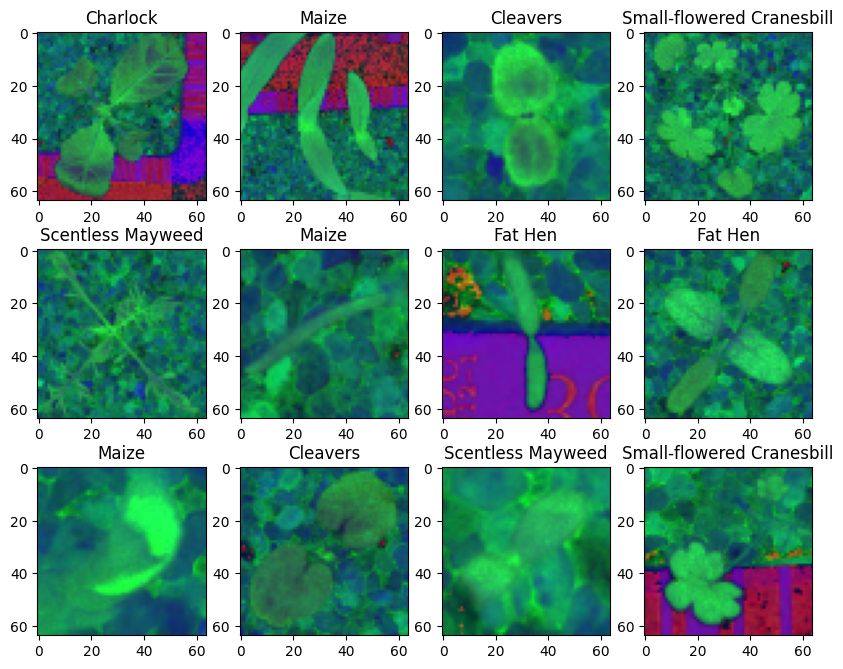

In [42]:
# view hsv images after size reduction
plot_images(images_hsv_decreased, labels)

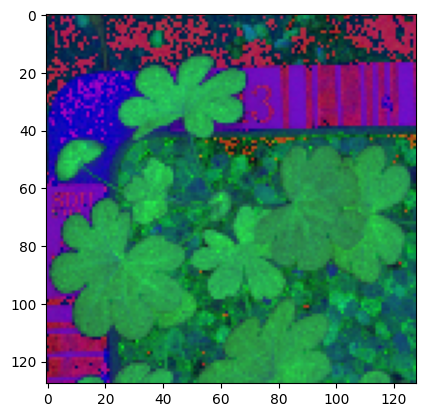

In [43]:
# view images before resizing
plt.imshow(images_hsv[3])

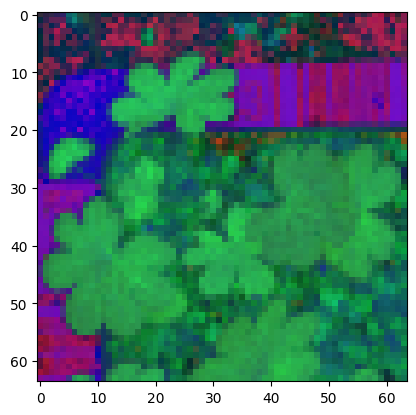

In [44]:
# view images after resizing
plt.imshow(images_hsv_decreased[3])

In [45]:
print('Original Shape RGB:', images_rgb[0].shape)
print('New Shape after Resizing RGB:', images_rgb_decreased[0].shape)
print('Original Shape HSV:', images_hsv[0].shape)
print('New Shape after Resizing HSV:', images_hsv_decreased[0].shape)

Original Shape RGB: (128, 128, 3)
New Shape after Resizing RGB: (64, 64, 3)
Original Shape HSV: (128, 128, 3)
New Shape after Resizing HSV: (64, 64, 3)


* The X and Y have have reduced to 64 x 64 from 128 x 128.
* There is still 3 channels including Red, Blue and Green
* Images look to be blurrier due to the removal of pixels.
* HSV looks to give more detail at a smaller pixel size, but the background does show up more as well.
* Looking into what additional techniques are available.
  * Gaussian Blurring - NO since the images due to resizing to a smaller size made the images blurry
  * Filtering on a color - YES, since the plants we are looking at are in the green family, I want to attempt to filter out the non-green and focus on the green

### Filtering HSV on Green

* The seedlings that are being classified are various shades of green. I want to see if I can filter just on the greens and remove most of the backgrounds since they tend to be other colors.

In [46]:
def filter_images(img):
  # set the lower and upper bounds for green hue.
  # Hue Range is between 35 and 85 for Green
  # Saturation and Value are high values like 50-255
  # Since lighting can effect hues, so give wiggle room for adjustments
  sensitivity = 35
  lower  = np.array([60 - sensitivity, 100, 50])
  upper = np.array([60 + sensitivity, 255, 255])

  # Create a mask for the green color using inRange function
  mask = cv2.inRange(img, lower, upper)

  # Perform bitwise AND on the original image arrays using the mask
  res = cv2.bitwise_and(img, img, mask=mask)

  return res

In [47]:
# loop through reduced hsv images, apply filter and save back to an array
filtered_hsv_decreased_images = []
for img in images_hsv_decreased:
  result = filter_images(img)
  filtered_hsv_decreased_images.append(result)
filtered_hsv_decreased_images = np.array(filtered_hsv_decreased_images)

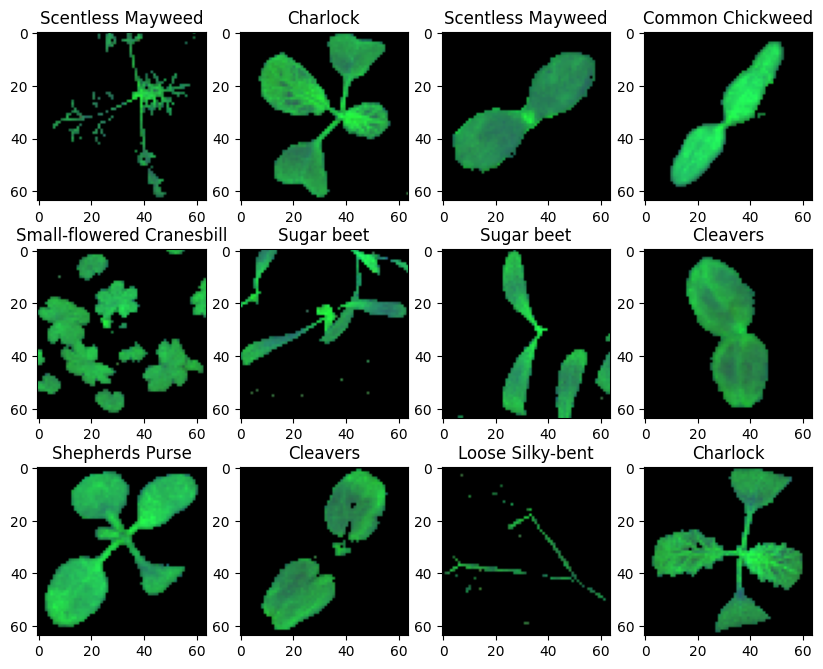

In [48]:
# view hsv images after size reduction and filters
plot_images(filtered_hsv_decreased_images, labels)

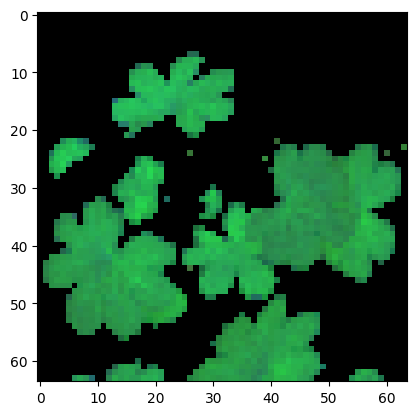

In [49]:
plt.imshow(filtered_hsv_decreased_images[3])

* Filtering on green removed the majority of the background and left the plant. This looks good, but there are some plants that have reduced in size as parts of it were filtered out.
* Going to move forward with both the hsv and the rgb data to see if one is working better than the other.

### Data Preparation for Modeling

- Before you proceed to build a model, you need to split the data into train, test, and validation to be able to evaluate the model that you build on the train data
- You'll have to encode categorical features and scale the pixel values.
- You will build a model using the train data and then check its performance

#### Split the dataset - RGB

In [50]:
# train test split for the RGB images
X_temp_rgb, X_test_rgb, y_temp_rgb, y_test_rgb = train_test_split(np.array(images_rgb_decreased), labels, test_size=0.1, random_state=42, stratify=labels)
X_train_rgb, X_val_rgb, y_train_rgb, y_val_rgb = train_test_split(X_temp_rgb, y_temp_rgb, test_size=0.1, random_state=42, stratify=y_temp_rgb)

In [51]:
 # View the shape of train, validation and test data for RGB images
print(X_train_rgb.shape, y_train_rgb.shape)
print(X_val_rgb.shape, y_val_rgb.shape)
print(X_test_rgb.shape, y_test_rgb.shape)

(3847, 64, 64, 3) (3847, 1)
(428, 64, 64, 3) (428, 1)
(475, 64, 64, 3) (475, 1)


#### Split the dataset - HSV

In [52]:
# train test split for HSV images
X_temp_hsv, X_test_hsv, y_temp_hsv, y_test_hsv = train_test_split(np.array(filtered_hsv_decreased_images), labels, test_size=0.1, random_state=42, stratify=labels)
X_train_hsv, X_val_hsv, y_train_hsv, y_val_hsv = train_test_split(X_temp_hsv, y_temp_hsv, test_size=0.1, random_state=42, stratify=y_temp_hsv)

In [53]:
 # View the shape of train, validation and test data for HSV images
print(X_train_hsv.shape, y_train_hsv.shape)
print(X_val_hsv.shape, y_val_hsv.shape)
print(X_test_hsv.shape, y_test_hsv.shape)

(3847, 64, 64, 3) (3847, 1)
(428, 64, 64, 3) (428, 1)
(475, 64, 64, 3) (475, 1)


* As expected, the training sets have about 81% of the data
* Validation has about 9% of the data
* Testing has 10% of the data

### Encode the target labels

In [54]:
# Encode Target Variable (y_train_rgb) using LabelBinarizer
enc = LabelBinarizer()
y_train_rgb_encoded = enc.fit_transform(y_train_rgb)
y_val_rgb_encoded = enc.transform(y_val_rgb)
y_test_rgb_encoded = enc.transform(y_test_rgb)

In [55]:
# check shape of train, validation and test data
y_train_rgb_encoded.shape, y_val_rgb_encoded.shape, y_test_rgb_encoded.shape

((3847, 12), (428, 12), (475, 12))

In [56]:
# Encode Target Variable (y_train_hsv) using LabelBinarizer
enc = LabelBinarizer()
y_train_hsv_encoded = enc.fit_transform(y_train_hsv)
y_val_hsv_encoded = enc.transform(y_val_hsv)
y_test_hsv_encoded = enc.transform(y_test_hsv)

In [57]:
# check shape of train, validation and test data
y_train_hsv_encoded.shape, y_val_hsv_encoded.shape, y_test_hsv_encoded.shape

((3847, 12), (428, 12), (475, 12))

* Encoding took the shape of the y values (target labels) in the y_train from (3847, 1) to (3847, 12) for the 12 categories

### Data Normalization

In [58]:
# Normalize the pixels for train, test and validation data for RGB
X_train_rgb_norm = X_train_rgb.astype('float32')/255.0
X_val_rgb_norm = X_val_rgb.astype('float32')/255.0
X_test_rgb_norm = X_test_rgb.astype('float32')/255.0

In [59]:
# Normalize the pixels for train, test and validation data for HSV
X_train_hsv_norm = X_train_hsv.astype('float32')/255.0
X_val_hsv_norm = X_val_hsv.astype('float32')/255.0
X_test_hsv_norm = X_test_hsv.astype('float32')/255.0

* The X data has been normalized and the y data (labels) have been encoded.
* Now, I will work on building 2 models. One for RGB and HSV. Which ever has the better performance, I will use in the Model Performance Improvement section

## Model Building

In [60]:
#Clear backend
backend.clear_session()

In [61]:
# Fix the seed for random number generators
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

### Initial Model - RGB

In [62]:
# Initilize Sequential Model
model_rgb = Sequential(name='INTIAL_MODEL_RGB')

# Conv layer with 128 filters, kernel size of 3x3, padding is the same
model_rgb.add(Conv2D(128, (3,3), activation='relu', padding='same', input_shape=(64,64,3)))

# Max pooling
model_rgb.add(MaxPooling2D(pool_size=(2,2), padding='same'))

# Add another Conv layer with 64 kernels of 3 x 3 size and same padding
model_rgb.add(Conv2D(64, (3,3), activation='relu', padding='same'))

# Add another Max pooling layer
model_rgb.add(MaxPooling2D(pool_size=(2,2), padding='same'))

# Add another Conv Layer with 32 kernals of 3 x 3 size and same padding
model_rgb.add(Conv2D(32, (3, 3), activation='relu', padding="same"))

# Add another Max pooling
model_rgb.add(MaxPooling2D((2, 2), padding = 'same'))

# Flattening the layer before the fully connected layers
model_rgb.add(Flatten())

# Fully connected dense layer with 16 neurons
model_rgb.add(Dense(16, activation='relu'))

# Add dropout of 0.3
model_rgb.add(Dropout(0.3))

# Add output layer with 12 neurons (total categories) with activation of softmax for multi-class classification
model_rgb.add(Dense(12, activation='softmax'))

# Initilize Adam Optimizer and compile model
adam_opt = Adam()
model_rgb.compile(optimizer=adam_opt, loss='categorical_crossentropy', metrics=['accuracy'])

# view model
model_rgb.summary()

Model: "INTIAL_MODEL_RGB"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 16, 16, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │          32,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 128,828 (503.23 KB)

 Trainable params: 128,828 (503.23 KB)

 Non-trainable params: 0 (0.00 B)

* Model "INITIAL_MODEL_RGB" with train and learn 128,828 paramters(weights and biases)
* We are using the loss function **categorical_crossentropy** as this is a multi-class classification problem
* For the metrics, we are using accuracy as the metric to measure the performance of the model

In [63]:
# fit the model on train
history = model_rgb.fit(
    X_train_rgb_norm,
    y_train_rgb_encoded,
    validation_data=(X_val_rgb_norm, y_val_rgb_encoded),
    batch_size=32,
    epochs=30,
    verbose=2
)

Epoch 1/30
121/121 - 12s - 103ms/step - accuracy: 0.1191 - loss: 2.4694 - val_accuracy: 0.1379 - val_loss: 2.4510
Epoch 2/30
121/121 - 11s - 89ms/step - accuracy: 0.1827 - loss: 2.3907 - val_accuracy: 0.2056 - val_loss: 2.2246
Epoch 3/30
121/121 - 1s - 10ms/step - accuracy: 0.2602 - loss: 2.1867 - val_accuracy: 0.2804 - val_loss: 2.1614
Epoch 4/30
121/121 - 1s - 9ms/step - accuracy: 0.2963 - loss: 2.0917 - val_accuracy: 0.3364 - val_loss: 1.9366
Epoch 5/30
121/121 - 1s - 10ms/step - accuracy: 0.3104 - loss: 2.0266 - val_accuracy: 0.3832 - val_loss: 1.8916
Epoch 6/30
121/121 - 1s - 11ms/step - accuracy: 0.3169 - loss: 1.9874 - val_accuracy: 0.3925 - val_loss: 1.8725
Epoch 7/30
121/121 - 2s - 19ms/step - accuracy: 0.3293 - loss: 1.9486 - val_accuracy: 0.3738 - val_loss: 1.7982
Epoch 8/30
121/121 - 1s - 9ms/step - accuracy: 0.3319 - loss: 1.9117 - val_accuracy: 0.3762 - val_loss: 1.7584
Epoch 9/30
121/121 - 1s - 9ms/step - accuracy: 0.3387 - loss: 1.8867 - val_accuracy: 0.3972 - val_loss:

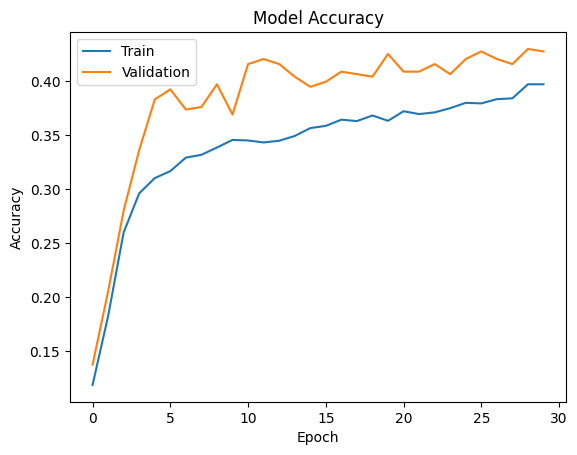

In [64]:
# Model Evaluation
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [65]:
# Evaluate the model on test data
accuracy = model_rgb.evaluate(X_test_rgb_norm, y_test_rgb_encoded)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.4810 - loss: 1.4812


* This model shows that the training accuracy was 40%, validation accuracy was 43% and test accuracy was 48%
* The current accuracy across the board is low, this can be from a number of potential reasons such as underfitting and insufficient training time.
* The test accuracy being the highest does indicate the model generalized well though the performance of the model was poor.


In [66]:
# Confusion Matrix
y_pred = model_rgb.predict(X_test_rgb_norm)


15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


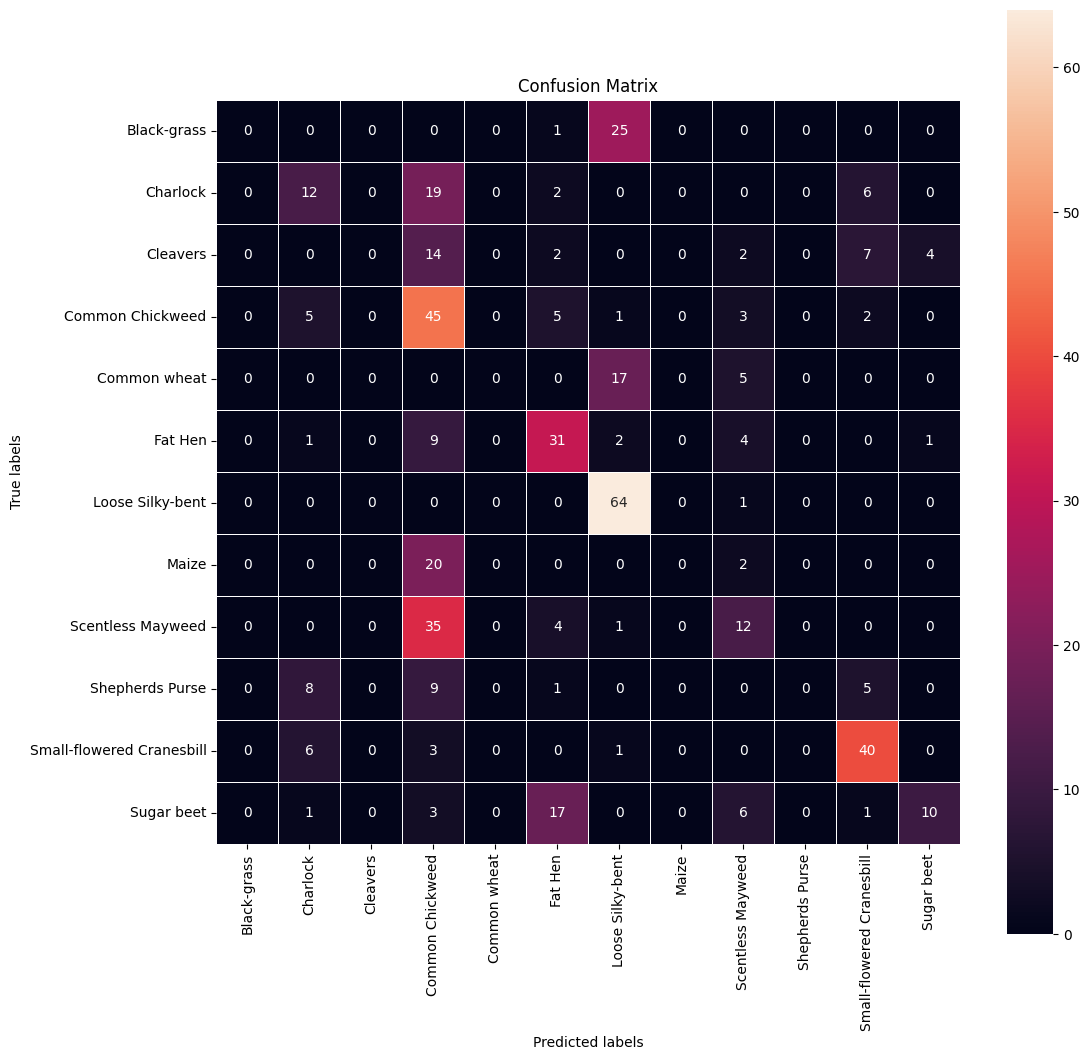

In [67]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred,axis=1)
y_test_arg=np.argmax(y_test_rgb_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined in tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg,y_pred_arg)
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=90)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=0)
plt.show()

* This model has issues identifying these seedlings:
  * `Black-grass` unable to be predicted correctly
  * `Charlock` mixed up with `Common Chickweed`
  * `Cleavers` unable to be predicted correctly
  * `Common Chickweed` predicted correcly majority of the time
  * `Common Wheat`unable to predict correctly
  * `Fat Hen` did well to predict majority
  * `Loose Silky-bent` predicted majority
  * `Maize` unable to be predicted correctly
  * `Scentless Mayweed` - predicted correctly some of the time but majority was incorrectly classified
  * `Shepherds Purse` unable to be predicted correctly
  * `Small-flowered Cranesbill` predicted majority correctly
  * `Sugar beet` - predicted correctly some of the time but majority was incorrectly classified

  * The intial RGB model has an overall accuracy of 48% in the testing data.

### Initial Model - HSV

* This model will be very similar to the RGB, but the images have had more pre processing done to them. Especially the addition of the Mask Filter that worked to isolate the green leaves of the seedlings

In [68]:
# Initilize Sequential Model
model_hsv = Sequential(name='INTIAL_MODEL_HSV')

# Conv layer with 128 filters, kernel size of 3x3, padding is the same
model_hsv.add(Conv2D(128, (3,3), activation='relu', padding='same', input_shape=(64,64,3)))

# Max pooling
model_hsv.add(MaxPooling2D(pool_size=(2,2), padding='same'))

# Add another Conv layer with 64 kernels of 3 x 3 size and same padding
model_hsv.add(Conv2D(64, (3,3), activation='relu', padding='same'))

# Add another Max pooling layer
model_hsv.add(MaxPooling2D(pool_size=(2,2), padding='same'))

# Add another Conv Layer with 32 kernals of 3 x 3 size and same padding
model_hsv.add(Conv2D(32, (3, 3), activation='relu', padding="same"))

# Add another Max pooling
model_hsv.add(MaxPooling2D((2, 2), padding = 'same'))

# Flattening the layer before the fully connected layers
model_hsv.add(Flatten())

# Fully connected dense layer with 16 neurons
model_hsv.add(Dense(16, activation='relu'))

# Add dropout of 0.3
model_hsv.add(Dropout(0.3))

# Add output layer with 12 neurons (total categories) with activation of softmax for multi-class classification
model_hsv.add(Dense(12, activation='softmax'))

# Initilize Adam Optimizer and compile model
adam_opt = Adam()
model_hsv.compile(optimizer=adam_opt, loss='categorical_crossentropy', metrics=['accuracy'])

# view model
model_hsv.summary()

Model: "INTIAL_MODEL_HSV"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 64, 64, 128)         │           3,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 32, 32, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 32, 32, 64)          │          73,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 16, 16, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 16, 16, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_5 (MaxPooling2D)       │ (None, 8, 8, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │          32,784 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 128,828 (503.23 KB)

 Trainable params: 128,828 (503.23 KB)

 Non-trainable params: 0 (0.00 B)

* Model "INITIAL_MODEL_HSV" with train and learn 128,828 paramters(weights and biases)
* We are using the loss function **categorical_crossentropy** as this is a multi-class classification problem
* For the metrics, we are using accuracy as the metric to measure the performance of the model

In [69]:
# fit the model on train
history = model_hsv.fit(
    X_train_hsv_norm,
    y_train_hsv_encoded,
    validation_data=(X_val_hsv_norm, y_val_hsv_encoded),
    batch_size=32,
    epochs=30,
    verbose=2
)

Epoch 1/30
121/121 - 8s - 67ms/step - accuracy: 0.2787 - loss: 2.1320 - val_accuracy: 0.3154 - val_loss: 1.9676
Epoch 2/30
121/121 - 1s - 10ms/step - accuracy: 0.3795 - loss: 1.7797 - val_accuracy: 0.4907 - val_loss: 1.5497
Epoch 3/30
121/121 - 1s - 9ms/step - accuracy: 0.4229 - loss: 1.5864 - val_accuracy: 0.5491 - val_loss: 1.4385
Epoch 4/30
121/121 - 1s - 11ms/step - accuracy: 0.4710 - loss: 1.4521 - val_accuracy: 0.5981 - val_loss: 1.2723
Epoch 5/30
121/121 - 1s - 11ms/step - accuracy: 0.4965 - loss: 1.3430 - val_accuracy: 0.6285 - val_loss: 1.1730
Epoch 6/30
121/121 - 1s - 11ms/step - accuracy: 0.5368 - loss: 1.2422 - val_accuracy: 0.6449 - val_loss: 1.1225
Epoch 7/30
121/121 - 1s - 11ms/step - accuracy: 0.5776 - loss: 1.1469 - val_accuracy: 0.6776 - val_loss: 0.9718
Epoch 8/30
121/121 - 2s - 19ms/step - accuracy: 0.6093 - loss: 1.0709 - val_accuracy: 0.6986 - val_loss: 0.9743
Epoch 9/30
121/121 - 1s - 11ms/step - accuracy: 0.6119 - loss: 1.0314 - val_accuracy: 0.6589 - val_loss: 

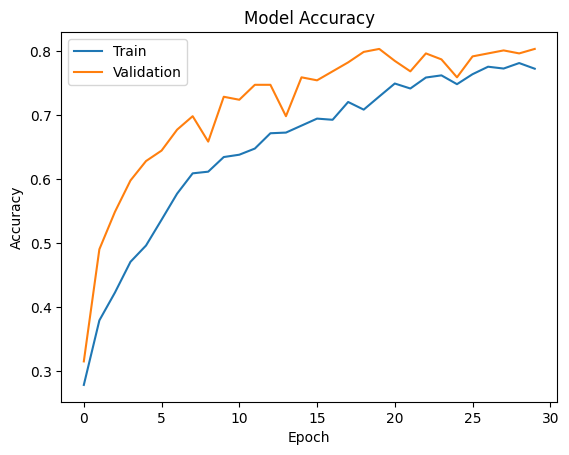

In [70]:
# Model Evaluation
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [71]:
# Evaluate the model on test data
accuracy = model_hsv.evaluate(X_test_hsv_norm, y_test_hsv_encoded)

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8237 - loss: 0.7089


* This model shows that the training accuracy was 77%, validation accuracy was 80% and test accuracy was 82%
* The training accuracy has improved alot from the RGB model, but there is still room to grow. The accuracy indicates that the model may be too simple or not enough time was used for training. From the graph, it looks like a few additional epochs might improve it.
* Since the training, validation and testing accuracy are similar, I would say the model has generalized relatively well.
* I will be moving forward with this HSV model to see if I can improve the accuracy further



In [72]:
# Confusion Matrix
y_pred = model_hsv.predict(X_test_hsv_norm)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


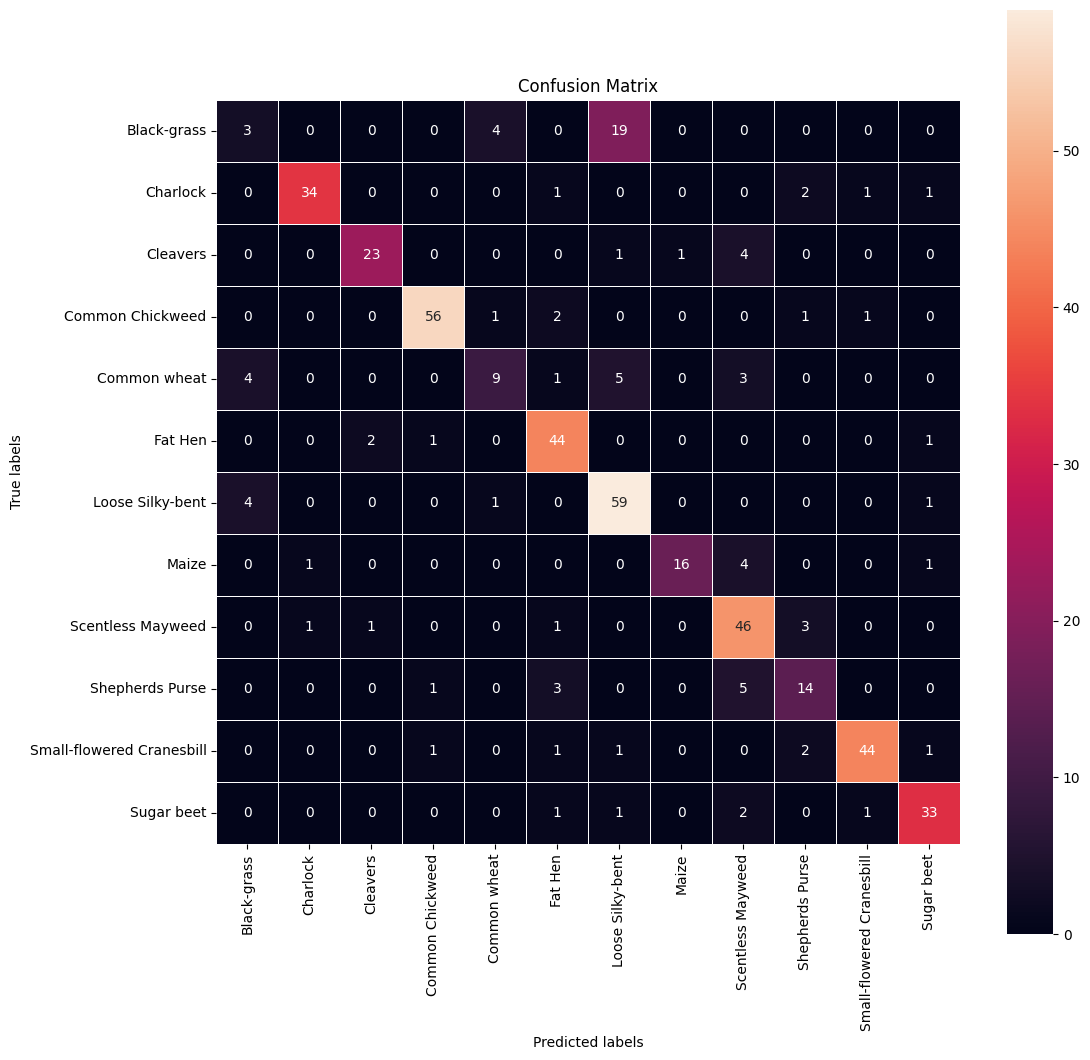

In [73]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred,axis=1)
y_test_arg=np.argmax(y_test_hsv_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined in tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg,y_pred_arg)
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=90)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=0)
plt.show()

* This model is mixing up these classifications (Actual vs Predicted):
  * `Black-grass vs Loose Silky-bent`
  * `Common wheat vs Loose Silky-bent`
  * `Maize vs Scentless Mayweed`
  * `Shepherds Purse vs Scentless Mayweed`
  * There is a bit of misclassifications through all of the species, but these are the most distinct

The initial HSV model has an test accuracy of 82% which isn't bad! Going forward I will focus on improving the initial HSV model.

## Model Performance Improvement

**Reducing the Learning Rate:**

**Hint**: Use **ReduceLRonPlateau()** function that will be used to decrease the learning rate by some factor, if the loss is not decreasing for some time. This may start decreasing the loss at a smaller learning rate. There is a possibility that the loss may still not decrease. This may lead to executing the learning rate reduction again in an attempt to achieve a lower loss.

In [74]:
# Code to monitor val_accuracy
learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=3,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

### **Data Augmentation**

Remember, **data augmentation should not be used in the validation/test data set**.

In [75]:
# Clearing backend
from tensorflow.keras import backend
backend.clear_session()

# Fixing the seed for random number generators
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [76]:
# set rotation range to 20
train_datagen = ImageDataGenerator(
                              rotation_range=20,
                              fill_mode='nearest'
                              )

In [77]:
model_hsv_1 = Sequential(name='HSV_data_augmentation')
model_hsv_1.add(Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(64, 64, 3)))
model_hsv_1.add(MaxPooling2D(pool_size=(2,2), padding='same'))

model_hsv_1.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model_hsv_1.add(MaxPooling2D(pool_size=(2,2), padding='same'))
model_hsv_1.add(BatchNormalization())

model_hsv_1.add(Flatten())
model_hsv_1.add(Dense(16, activation='relu'))
model_hsv_1.add(Dropout(0.3))
model_hsv_1.add(Dense(12, activation='softmax'))

adam_optimizer = Adam()
model_hsv_1.compile(optimizer=adam_optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

model_hsv_1.summary()

Model: "HSV_data_augmentation"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 64, 64, 64)          │           1,792 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 32, 32, 32)          │          18,464 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 16, 16, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16, 16, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 16)                  │         131,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 12)                  │             204 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 151,676 (592.48 KB)

 Trainable params: 151,612 (592.23 KB)

 Non-trainable params: 64 (256.00 B)

* Model "HSV_data_augmentation" with train and learn 151676 paramters(weights and biases)
* We are using the loss function **categorical_crossentropy** as this is a multi-class classification problem
* For the metrics, we are using accuracy as the metric to measure the performance of the model

In [78]:
# fit the model on train data
history = model_hsv_1.fit(train_datagen.flow(X_train_hsv_norm,y_train_hsv_encoded,
                                       batch_size=64,
                                       shuffle=False),
                                       epochs=30,
                                       steps_per_epoch=X_train_hsv_norm.shape[0],
                                       validation_data=(X_val_hsv_norm,y_val_hsv_encoded),
                                       verbose=1,callbacks=[learning_rate_reduction])

Epoch 1/30
3847/3847 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.2978 - loss: 2.1004 - val_accuracy: 0.3855 - val_loss: 2.3785 - learning_rate: 0.0010
Epoch 2/30
3847/3847 ━━━━━━━━━━━━━━━━━━━━ 14s 1ms/step - accuracy: 0.4643 - loss: 1.6277 - val_accuracy: 0.4556 - val_loss: 2.2949 - learning_rate: 0.0010
Epoch 3/30
3847/3847 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.5405 - loss: 1.3670 - val_accuracy: 0.5234 - val_loss: 2.2268 - learning_rate: 0.0010
Epoch 4/30
3847/3847 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6002 - loss: 1.1862 - val_accuracy: 0.5841 - val_loss: 2.0683 - learning_rate: 0.0010
Epoch 5/30
3847/3847 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.6332 - loss: 1.0798 - val_accuracy: 0.6659 - val_loss: 1.6553 - learning_rate: 0.0010
Epoch 6/30
3847/3847 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step - accuracy: 0.6541 - loss: 0.9803 - val_accuracy: 0.6799 - val_loss: 1.4327 - learning_rate: 0.0010
Epoch 7/30
3847/3847 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - accuracy: 0.6925 -

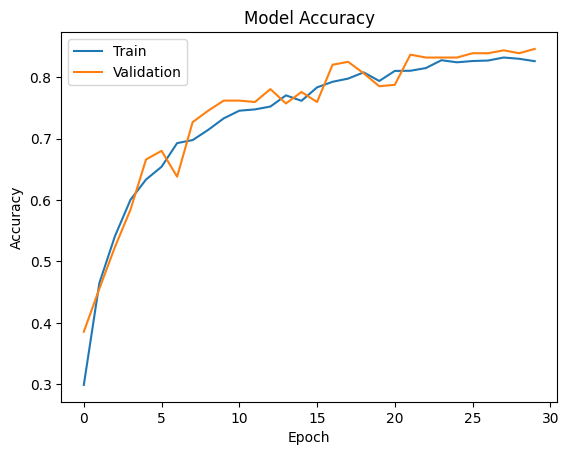

In [79]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

In [80]:
# Evaluate the model on test data
accuracy = model_hsv_1.evaluate(X_test_hsv_norm, y_test_hsv_encoded)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.8647 - loss: 0.4626


* This model shows that the training accuracy was 83%, validation accuracy was 85% and test accuracy was 86%
* This model seems to be generalizing well with no signs of over or underfitting.
* It looks like this model adjusted it's learning rate 3 different times


In [81]:
# Confusion Matrix
y_pred = model_hsv_1.predict(X_test_hsv_norm)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step


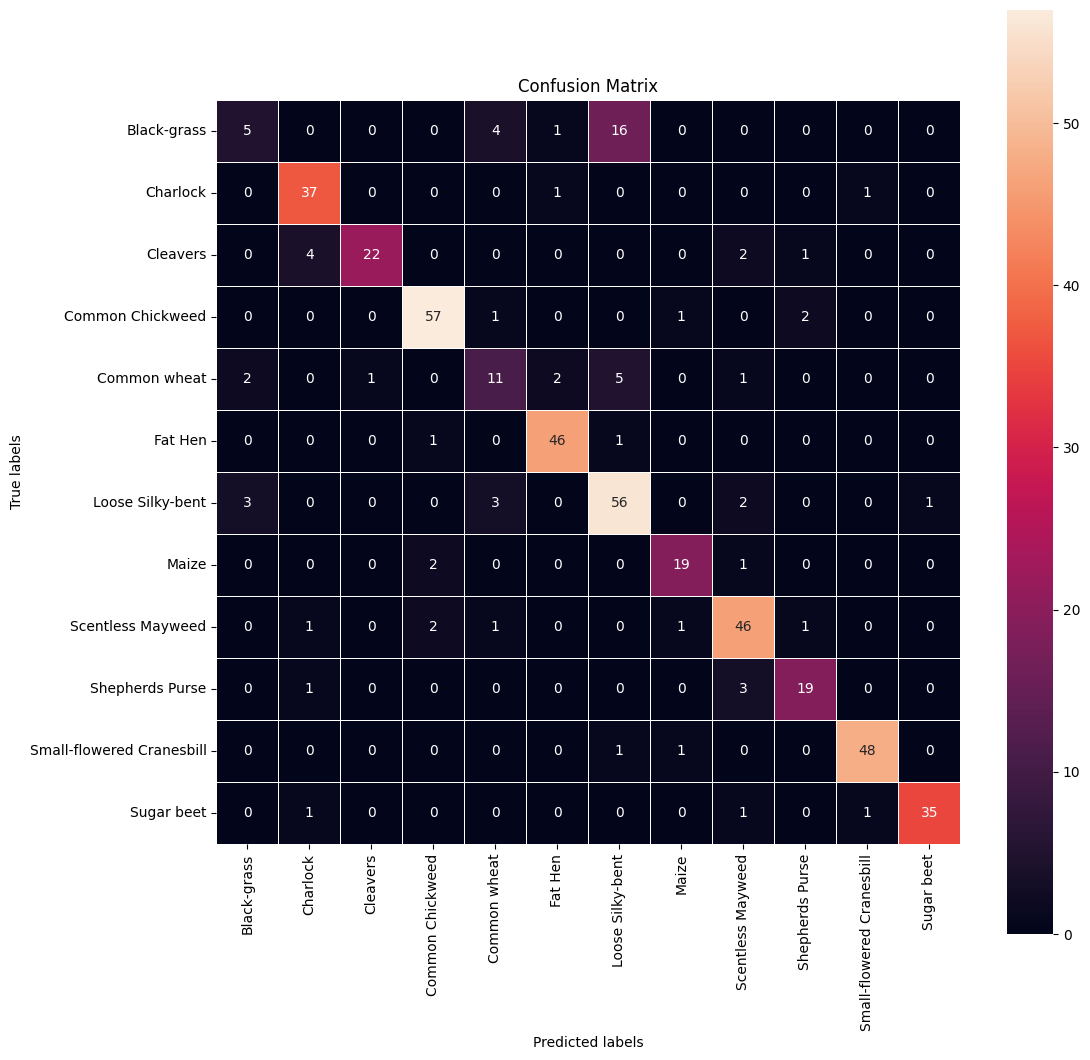

In [82]:
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred,axis=1)
y_test_arg=np.argmax(y_test_hsv_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined in tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg,y_pred_arg)
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=90)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=0)
plt.show()

In [83]:
target_names = enc.classes_
target_names

array(['Black-grass', 'Charlock', 'Cleavers', 'Common Chickweed',
       'Common wheat', 'Fat Hen', 'Loose Silky-bent', 'Maize',
       'Scentless Mayweed', 'Shepherds Purse',
       'Small-flowered Cranesbill', 'Sugar beet'], dtype='<U25')

In [84]:
# Classification Report
cr = metrics.classification_report(y_test_arg, y_pred_arg, target_names=target_names )
print(cr)

                           precision    recall  f1-score   support

              Black-grass       0.50      0.19      0.28        26
                 Charlock       0.84      0.95      0.89        39
                 Cleavers       0.96      0.76      0.85        29
         Common Chickweed       0.92      0.93      0.93        61
             Common wheat       0.55      0.50      0.52        22
                  Fat Hen       0.92      0.96      0.94        48
         Loose Silky-bent       0.71      0.86      0.78        65
                    Maize       0.86      0.86      0.86        22
        Scentless Mayweed       0.82      0.88      0.85        52
          Shepherds Purse       0.83      0.83      0.83        23
Small-flowered Cranesbill       0.96      0.96      0.96        50
               Sugar beet       0.97      0.92      0.95        38

                 accuracy                           0.84       475
                macro avg       0.82      0.80      0.80    

The HSV model with data augmentation has an overall accuracy of 84% and a test accuracy of 86%.

  * `Black-grass` improved the number of correct predictions, but majority of the time, it is being classified as `Loose Silky-bent`. Classified correctly 5/26 times
  * `Charlock` classified correctly 37/39 times
  * `Cleavers` classified correctly 22/29 times
  * `Common Chickweed` classified correctly 57/61 times
  * `Common Wheat`improved the number of correct predictions, but it is getting mixed up with `Loose Silky-bent` Classified correctly 11/22 times
  * `Fat Hen` classified correctly 46/48 times
  * `Loose Silky-bent` classified correctly 56/65 times
  * `Maize` classified correctly 19/22 times
  * `Scentless Mayweed` classified correctly 46/52 times
  * `Shepherds Purse` classified correctly 19/23 times
  * `Small-flowered Cranesbill` classified correctly 48/50 times
  * `Sugar beet` - classified correctly 35/38 times

  * The model has some confusion between (actual vs predicted):
    * `Black-grass vs Loose Silky-bent`
    * `Common Wheat vs Loose Silky-bent`


## Final Model

Comment on the final model you have selected and use the same in the below code to visualize the image.

* My final model is the HSV model with Data Augmentation.
* The model generalized well with the consistant accuracy across train, validation and testing being within a percentage of each other.
* The slight increase in accuracy on the test set indicates that the model has been learning the meaningful patterns that apply to the new data.

### Visualizing the prediction

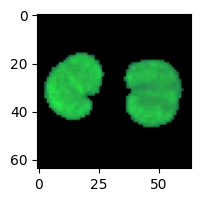

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step
Predicted Label ['Small-flowered Cranesbill']
True Label Small-flowered Cranesbill


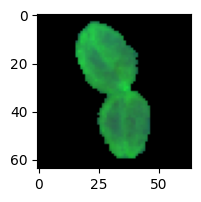

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Predicted Label ['Cleavers']
True Label Cleavers


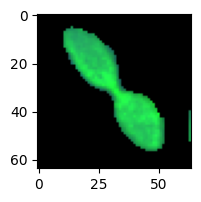

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Predicted Label ['Common Chickweed']
True Label Common Chickweed


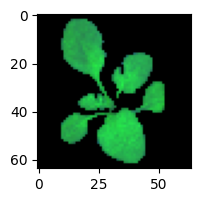

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Predicted Label ['Fat Hen']
True Label Fat Hen


In [85]:
# Visualizing the predicted and correct label of images from test data
plt.figure(figsize=(2,2))
plt.imshow(X_test_hsv[2])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model_hsv_1.predict((X_test_hsv_norm[2].reshape(1,64,64,3)))))   # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_hsv_encoded)[2])                                               # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test_hsv[33])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model_hsv_1.predict((X_test_hsv_norm[33].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_hsv_encoded)[33])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test_hsv[59],)
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model_hsv_1.predict((X_test_hsv_norm[59].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_hsv_encoded)[59])                                              # using inverse_transform() to get the output label from the output vector

plt.figure(figsize=(2,2))
plt.imshow(X_test_hsv[36])
plt.show()
## Complete the code to predict the test data using the final model selected
print('Predicted Label', enc.inverse_transform(model_hsv_1.predict((X_test_hsv_norm[46].reshape(1,64,64,3)))))  # reshaping the input image as we are only trying to predict using a single image
print('True Label', enc.inverse_transform(y_test_hsv_encoded)[46])                                              # using inverse_transform() to get the output label from the output vector

* Randomly chose numbers, the model predicted correctly!

In [86]:
# Classification Report for test
cr = metrics.classification_report(y_test_arg, y_pred_arg,target_names=target_names)
print(cr)

                           precision    recall  f1-score   support

              Black-grass       0.50      0.19      0.28        26
                 Charlock       0.84      0.95      0.89        39
                 Cleavers       0.96      0.76      0.85        29
         Common Chickweed       0.92      0.93      0.93        61
             Common wheat       0.55      0.50      0.52        22
                  Fat Hen       0.92      0.96      0.94        48
         Loose Silky-bent       0.71      0.86      0.78        65
                    Maize       0.86      0.86      0.86        22
        Scentless Mayweed       0.82      0.88      0.85        52
          Shepherds Purse       0.83      0.83      0.83        23
Small-flowered Cranesbill       0.96      0.96      0.96        50
               Sugar beet       0.97      0.92      0.95        38

                 accuracy                           0.84       475
                macro avg       0.82      0.80      0.80    

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


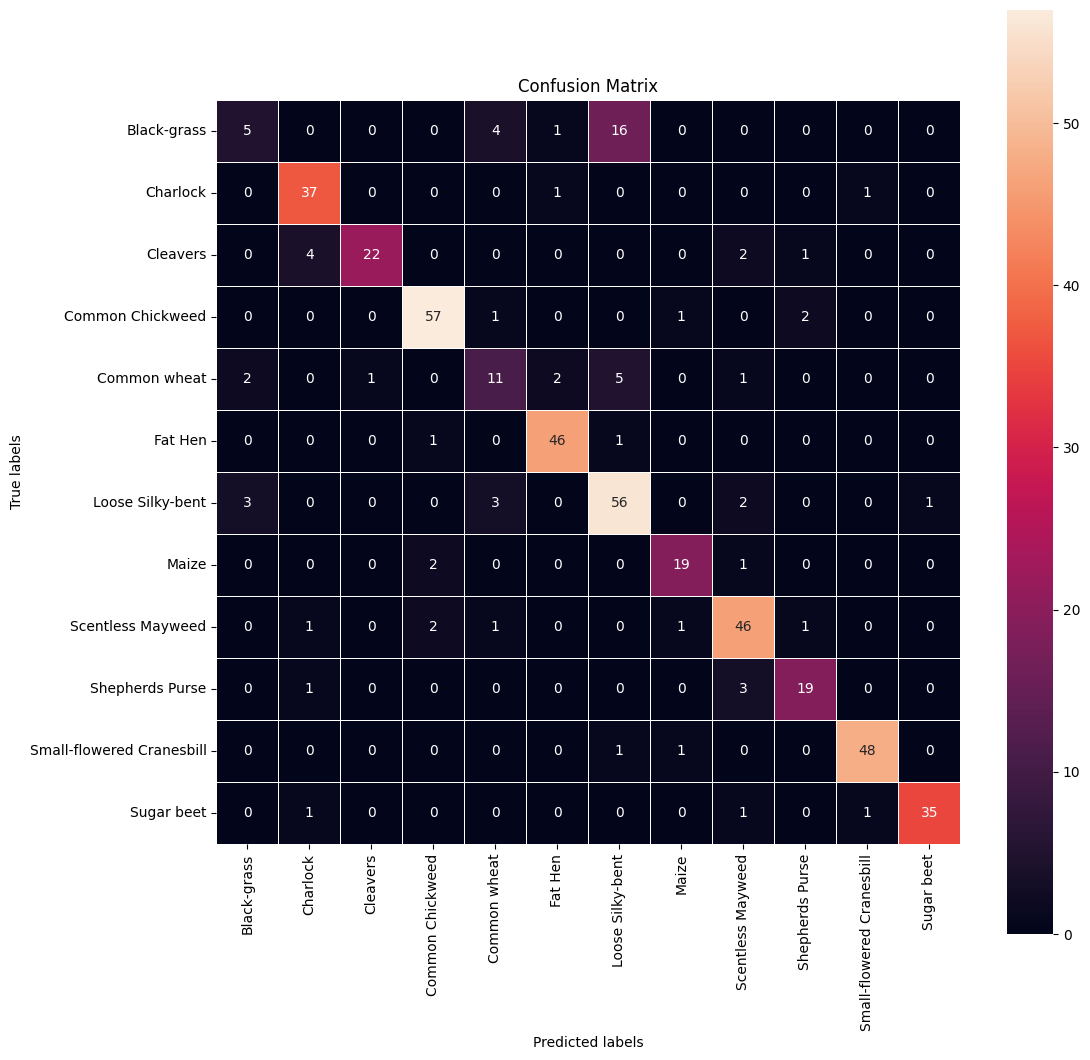

In [87]:
# Confusion Matrix for test data
y_pred_test = model_hsv_1.predict(X_test_hsv_norm)
# Obtaining the categorical values from y_test_encoded and y_pred
y_pred_arg=np.argmax(y_pred_test,axis=1)
y_test_arg=np.argmax(y_test_hsv_encoded,axis=1)

# Plotting the Confusion Matrix using confusion matrix() function which is also predefined in tensorflow module
confusion_matrix = tf.math.confusion_matrix(y_test_arg,y_pred_arg)
f, ax = plt.subplots(figsize=(12, 12))
sns.heatmap(
    confusion_matrix,
    annot=True,
    linewidths=.4,
    fmt="d",
    square=True,
    ax=ax
)
# Setting the labels to both the axes
ax.set_xlabel('Predicted labels');ax.set_ylabel('True labels');
ax.set_title('Confusion Matrix');
ax.xaxis.set_ticklabels(list(enc.classes_),rotation=90)
ax.yaxis.set_ticklabels(list(enc.classes_),rotation=0)
plt.show()

* The model has an overall accuracy of 84% which means the model classifies the correct seedling 84% of the time.
* It seems areas where the model struggled were:
  * Black-Grass vs Loose Silky-bent
  * Common Wheat vs Loose Silky-bent
  * The f1 score for Black-Grass and Common Wheat were 28 and 52 while majority 83+

* Need to explore the images of these 3 seedlings to see why the model might have some confusion between them.


In [95]:
def plot_images_by_indices(specific_label, indices, filtered_images, filtered_images_hsv, masked_images):
    # Ensure that there are images to plot for the provided indices
    if len(indices) == 0:
        print(f"No images provided to plot for the label: {specific_label}.")
        return

    # Calculate the number of rows based on the number of indices
    n_images = len(indices)
    n_cols = 3  # 3 columns: one for each variation
    n_rows = n_images  # 1 row per plant

    # Create the grid of subplots: 3 columns, n_images rows
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))

    # Flatten the axes array for easier indexing
    axes = axes.flatten()

    # Plot the images in the grid
    for i, index in enumerate(indices):
        # Plot the filtered images variation (first column)
        axes[i * 3].imshow(filtered_images[index])
        axes[i * 3].axis('off')
        axes[i * 3].set_title("Original Image")

        # Plot the filtered_hsv variation (second column)
        axes[i * 3 + 1].imshow(filtered_images_hsv[index])
        axes[i * 3 + 1].axis('off')
        axes[i * 3 + 1].set_title("HSV Images")

        # Plot the masked images variation (third column)
        axes[i * 3 + 2].imshow(masked_images[index])
        axes[i * 3 + 2].axis('off')
        axes[i * 3 + 2].set_title("Masked Image")

    # Set the title for the whole plot
    fig.suptitle(specific_label, fontsize=20, fontweight='bold', y=1.0)

    # Adjust layout to avoid overlap
    plt.tight_layout()

    # Show the plot
    plt.show()



In [89]:
labels['Label'].unique()

array(['Small-flowered Cranesbill', 'Fat Hen', 'Shepherds Purse',
       'Common wheat', 'Common Chickweed', 'Charlock', 'Cleavers',
       'Scentless Mayweed', 'Sugar beet', 'Maize', 'Black-grass',
       'Loose Silky-bent'], dtype=object)

In [90]:
# filter on Loose Silky-bent
indices = labels[labels['Label'] == 'Loose Silky-bent'].index
filtered_images = images[indices]
filtered_images_hsv = images_hsv_decreased[indices]
masked_images = filtered_hsv_decreased_images[indices]

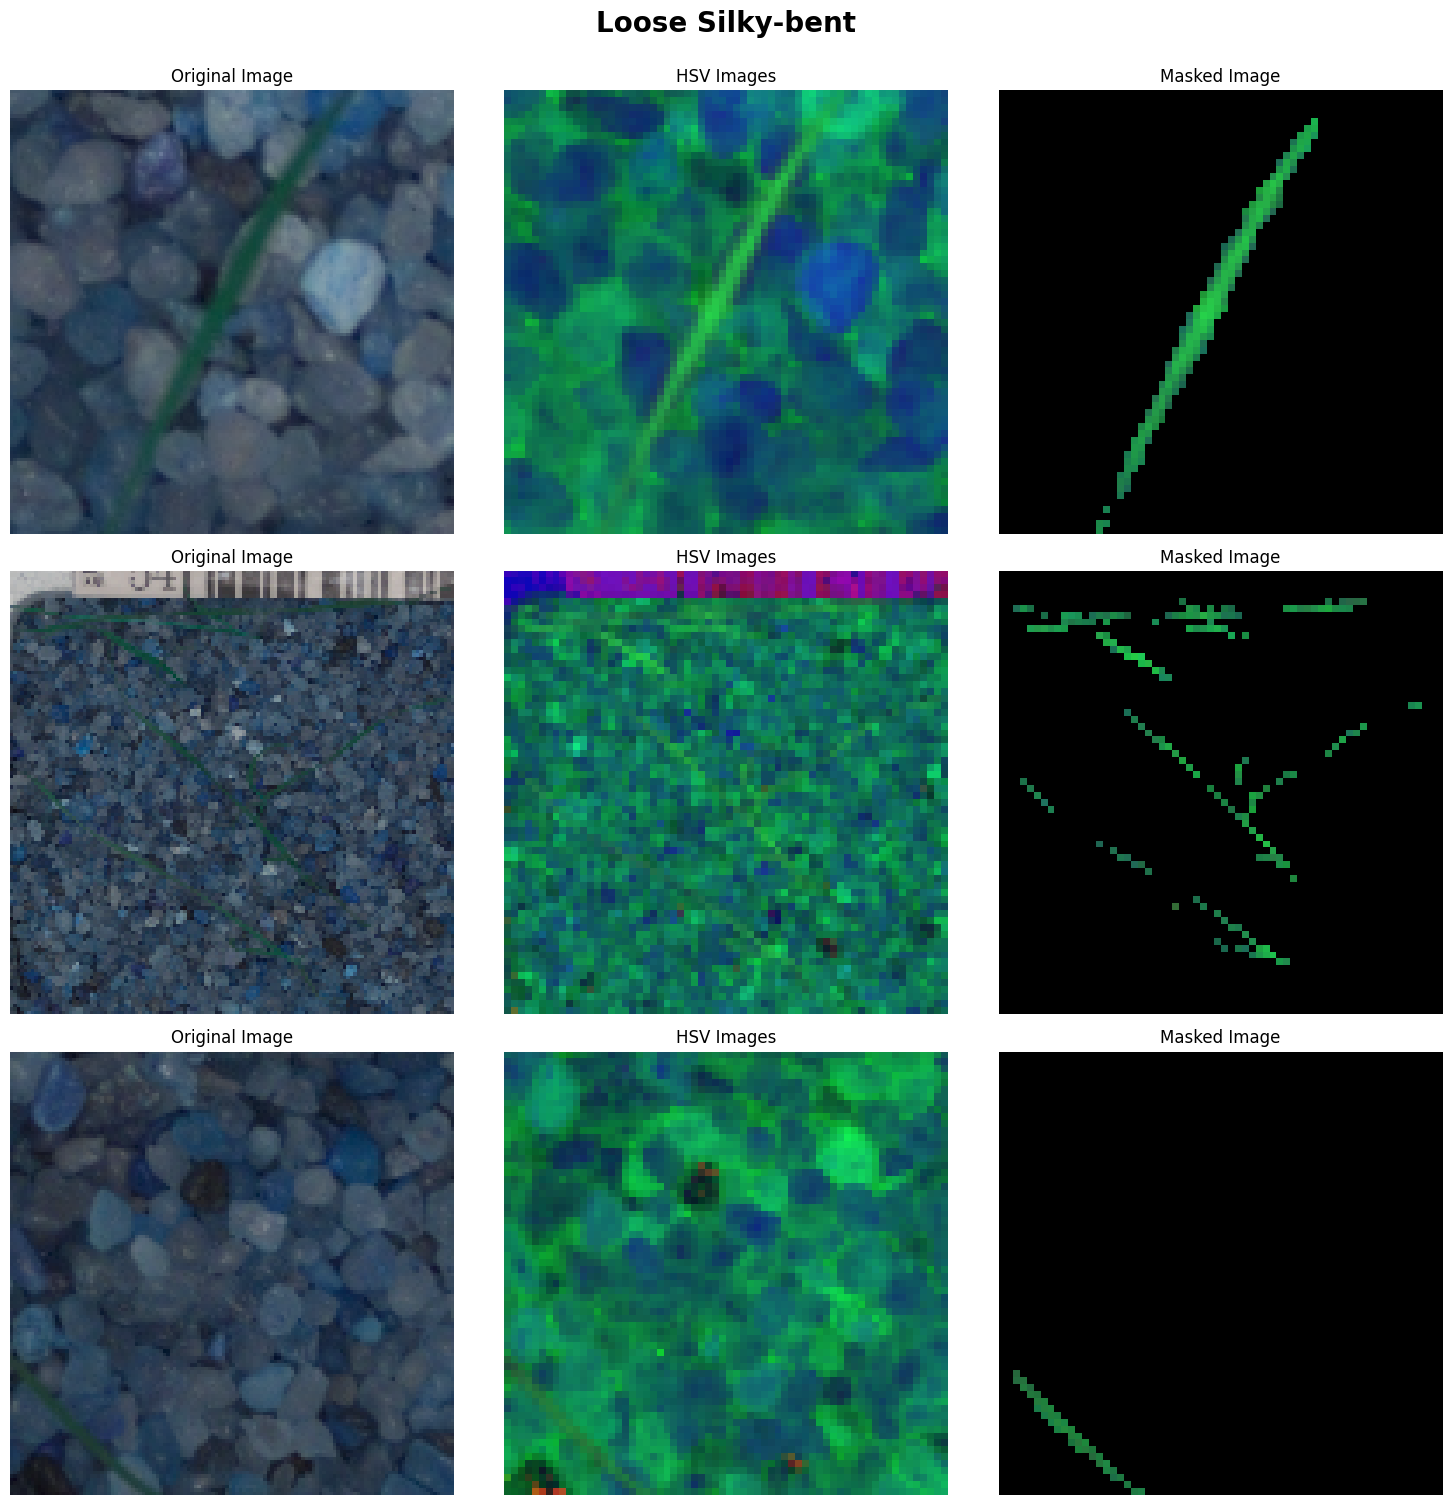

In [91]:
plot_images_by_indices('Loose Silky-bent', [3, 17, 27], filtered_images, filtered_images_hsv, masked_images)

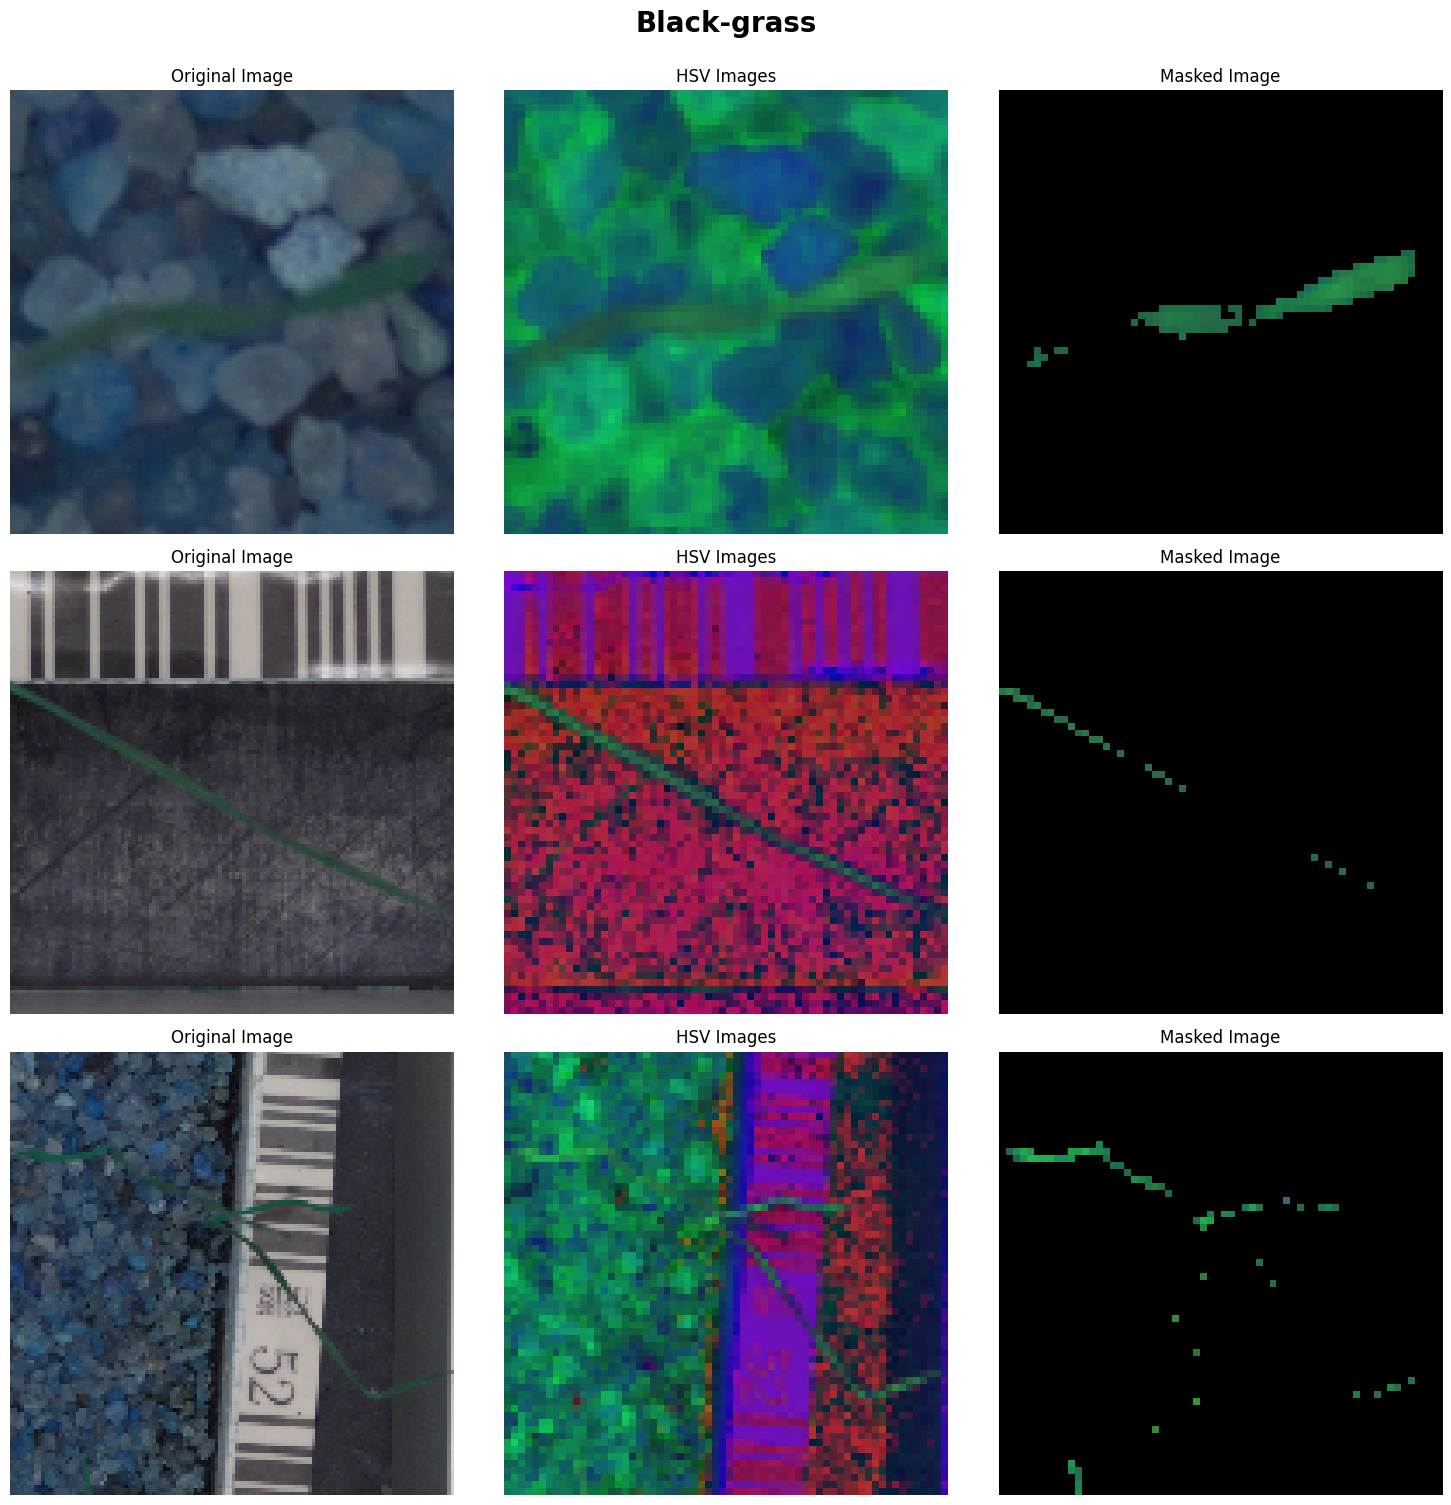

In [92]:
# Filter and plot Black-grass
indices = labels[labels['Label'] == 'Black-grass'].index
filtered_images = images[indices]
filtered_images_hsv = images_hsv_decreased[indices]
masked_images = filtered_hsv_decreased_images[indices]
plot_images_by_indices('Black-grass', [3, 17, 27], filtered_images, filtered_images_hsv, masked_images)

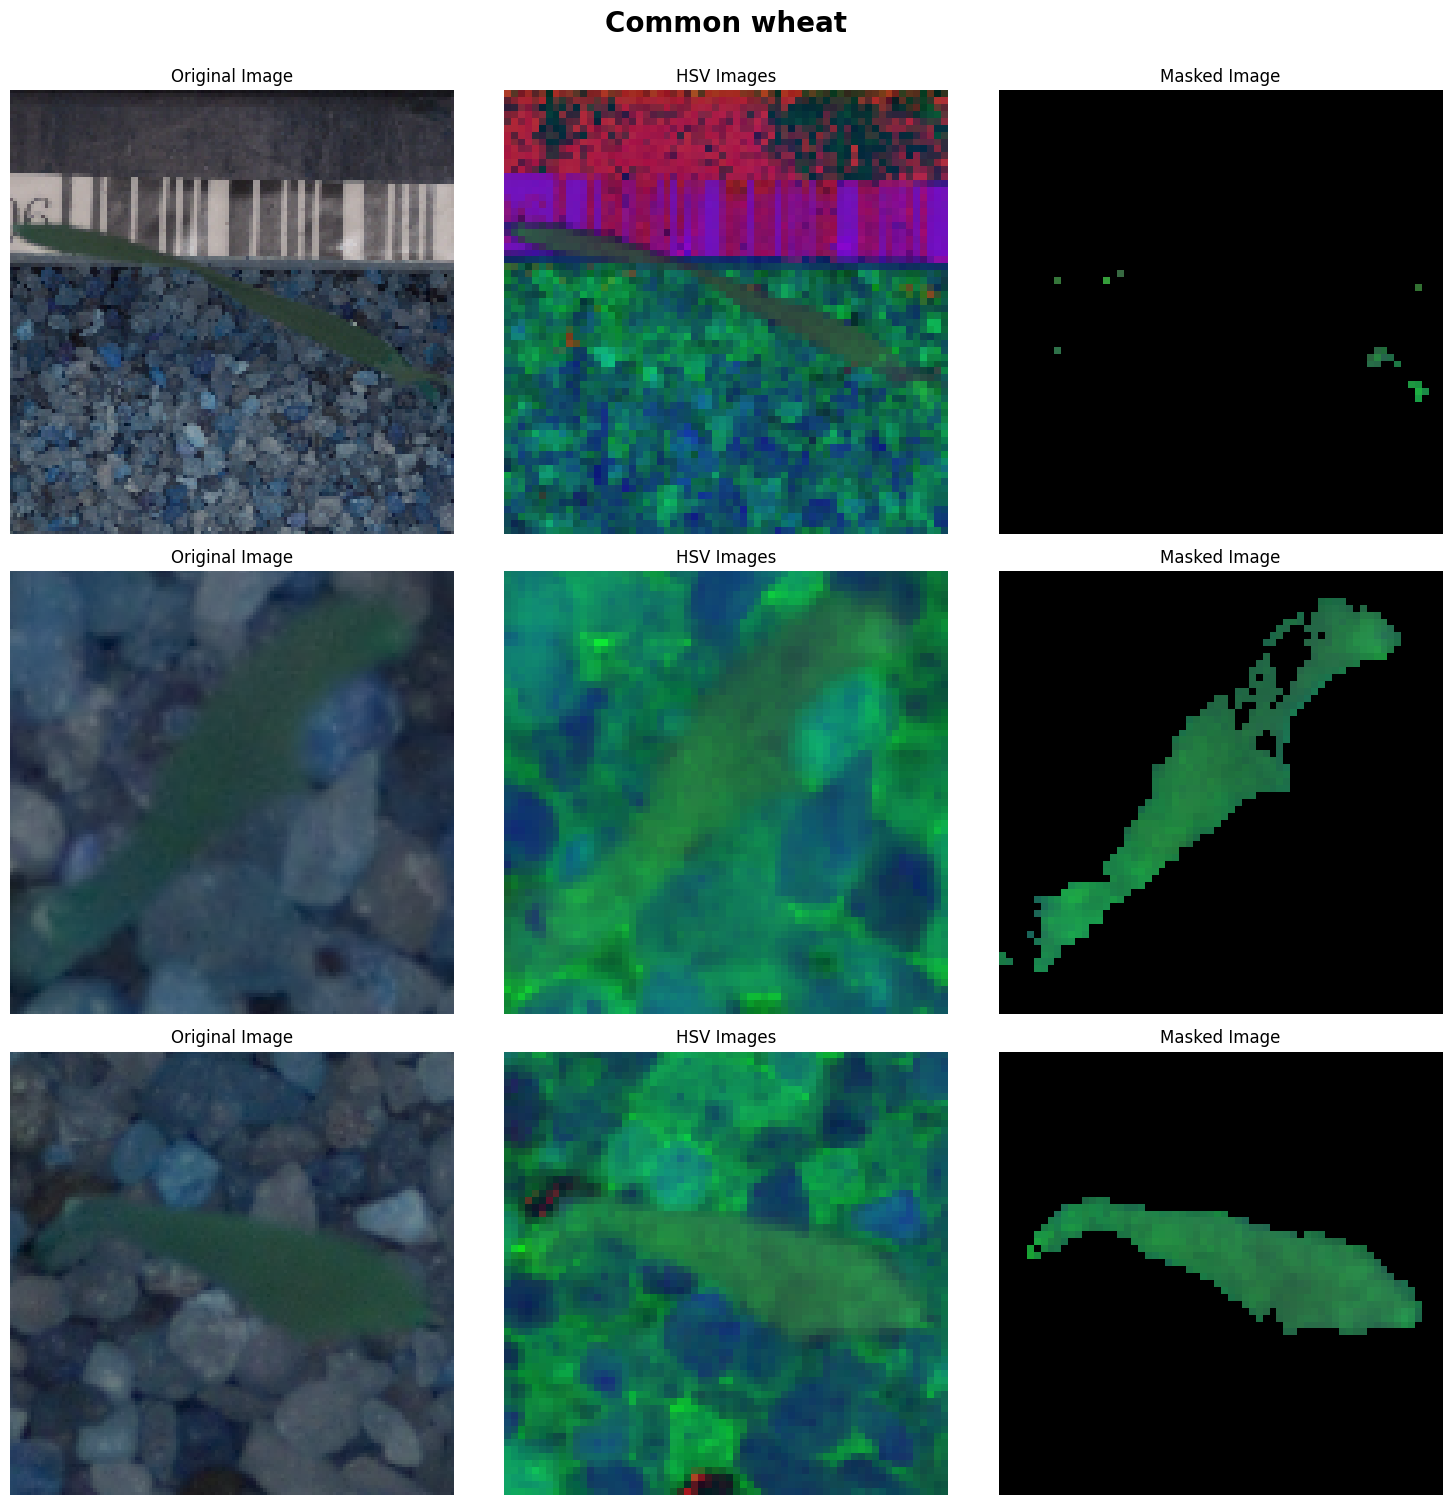

In [93]:
# Filter and plot Common Wheat
indices = labels[labels['Label'] == 'Common wheat'].index
filtered_images = images[indices]
filtered_images_hsv = images_hsv_decreased[indices]
masked_images = filtered_hsv_decreased_images[indices]
plot_images_by_indices('Common wheat', [3, 17, 27], filtered_images, filtered_images_hsv, masked_images)

In [94]:
labels.value_counts()

,count
Label,
Loose Silky-bent,654
Common Chickweed,611
Scentless Mayweed,516
Small-flowered Cranesbill,496
Fat Hen,475
Charlock,390
Sugar beet,385
Cleavers,287
Black-grass,263


## Actionable Insights and Business Recommendations

**Overview**
* The model that performed the best and would be the first choice went through image size reduction, conversion to HSV, filtered with a green mask, data augmented and finally trained with a variable learning rate.
* I suspect the convolution filters helped to detect the edges both horizontal and verticle. As the images became blurry when reduced in size so did the distinct edges.

* The model has an overall accuracy of 84% which means the model classifies the correct seedling 84% of the time.
* It seems areas where the model struggled were:
  * Black-Grass vs Loose Silky-bent
  * Common Wheat vs Loose Silky-bent

* Loose Silky-bent has the most samples of all the plants while Black Grass and Common Wheat have significantly less samples. Having viewed samples of each above it is easy to tell that all 3 share similar traits with each other.

* Black Grass and Loose Silky-bent are both long thin seedlings. I noticed that when applying my mask to the already blurry (reduced) images, there tended to be gaps in the plants being highlighted and in some cases, missing the majority or all of the plant. This leads me to believe that in cases like that, Loose Silky-bent being weightened more just based on the larger sample size might played a role in why the prediction was Loose Silky-bent instead of Black Grass.

* Common Wheat has around a third of the samples in comparison to Loose Silky-bent. As mentioned above, the mask filter almost completely filtered out parts of the seedlings. Common Wheat tends to be a long thick seedling so the length plus a reduced thickness due to the filter, might have made the model think the Common Wheat was Loose Silky-bent.

**Model Improvements**
* The model was pretty accurate, but the filter needs to be tweaked to prevent it from filtering out as much of the plant.
* The Convolution filters helped to detect edges, but it might have faltered due to the image size reduction causing the images to blur. Perhaps, a sharpening filter could be used before masking to help define the plant edges.
* It would be suggested to increase the number of seedling samples for Common Wheat and Black-Grass to help the model better learn features from those types of seedlings.
* I would also encourage the model be optimized through hyperparamter tuning or connected through Transfer Learning to improve the accuracy.


**Suggestions**

* Try to improve the best model (model_hsv_1) accuracy by changing the hyperparamters such as:
  * Number of filters
  * Types of Filters
  * Filter Size
  * Activation Function
  * Drop out ratio
* Improve the masking filter
  * Use an interactive track bar to dynamically adjust hsv range to find one that highlights more of the seedlings and update lower and upper hsv boundaries.
* This model can be used to identify plants from images with 84% accuracy. Since it struggles a little with Common Wheat and Black Grass, and Loose Silky-bent, there might be a need to check the classifications regularly to ensure that the model isn't defaulting to Silky-bent on images that might be cut off from the filter.





_____